### Imports

In [42]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Running in Google Colab")

    repo_dir = "/content/keyboard_sound"  # fixed absolute path

    if not os.path.exists(repo_dir):
        !git clone https://github.com/ayushma18/keyboard_sound {repo_dir}

    %cd {repo_dir}

    !pip install -r requirements_colab.txt

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import librosa
import os
import random
import seaborn as sns
import pandas as pd
import pickle
import torchaudio
import soundfile as sf

from torchaudio.transforms import TimeMasking, FrequencyMasking
from torchinfo import summary
from tqdm import tqdm
from torchvision import datasets, transforms
from collections import defaultdict
from torchvision.transforms import Compose, ToTensor
from torch.utils.data import DataLoader, Dataset
from scipy.io import wavfile
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

pd.set_option('future.no_silent_downcasting', True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_4732\1340087408.py:28: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [57]:
data_path= "Data/segmented/alphanum-400"  # Contains 0-9 and a-z (36 classes)
noise_path="model/Noises"
best_model_path = f"model/CNN-Best-{data_path.split('/')[-1]}.pkl"
model_path = f"model/CNN-Final-{data_path.split('/')[-1]}.pkl"

### 📌 Dataset Selection

Available datasets in `Data/segmented/`:
- **`alpha-large`** - 26 classes (a-z only)
- **`alphanum-400`** - 36 classes (0-9 and a-z) ✅ **Currently selected**
- **`alphanum-hard-100`** - 36 classes with harder conditions
- **`alphanum-soft-100`** - 36 classes with softer conditions
- **`num-large`** - 10 classes (0-9 only)

Change `data_path` in the cell below to switch datasets.

### Noise Library Loader & Analyzer

In [73]:
class NoiseLibrary:
    """
    Load and analyze all noise samples for augmentation.
    Stores metadata about each noise: length, RMS level, etc.
    """
    def __init__(self, noise_dir=noise_path):
        self.noise_dir = noise_dir
        self.noises = {
            'city': [],
            'classroom': [],
            'office': [],
            'common': []
        }
        self.noise_metadata = []
        self.load_all_noises()

    def load_all_noises(self):
        """Load all noise files and compute their metadata"""
        print("Loading noise library...")

        # Define category mapping
        categories = {
            'city': 'city',
            'classroom': 'classroom',
            'office': 'office',
            'Common Noises': 'common'
        }

        for category_folder, category_key in categories.items():
            category_path = os.path.join(self.noise_dir, category_folder)
            if not os.path.exists(category_path):
                print(f"Warning: {category_path} not found")
                continue

            for filename in os.listdir(category_path):
                if filename.endswith(('.wav', '.mp3', '.flac', '.ogg')):
                    file_path = os.path.join(category_path, filename)
                    try:
                        # Load audio using soundfile directly (more reliable)
                        import soundfile as sf
                        try:
                            # Try torchaudio first
                            waveform, sr = torchaudio.load(file_path)
                        except (ImportError, RuntimeError):
                            # Fallback to soundfile if torchaudio fails
                            audio_data, sr = sf.read(file_path)
                            waveform = torch.from_numpy(audio_data).float()
                            if waveform.ndim == 1:
                                waveform = waveform.unsqueeze(0)
                            elif waveform.ndim == 2:
                                waveform = waveform.T

                        # Convert to mono if stereo
                        if waveform.shape[0] > 1:
                            waveform = torch.mean(waveform, dim=0, keepdim=True)

                        # Resample to 44.1kHz if needed
                        if sr != 44100:
                            resampler = torchaudio.transforms.Resample(sr, 44100)
                            waveform = resampler(waveform)

                        # Calculate RMS (Root Mean Square) for noise level
                        rms = torch.sqrt(torch.mean(waveform ** 2)).item()

                        noise_info = {
                            'category': category_key,
                            'waveform': waveform,
                            'length': waveform.shape[1],
                            'rms': rms,
                            'filename': filename
                        }

                        self.noises[category_key].append(noise_info)
                        self.noise_metadata.append(noise_info)

                    except Exception as e:
                        print(f"Error loading {file_path}: {e}")

        # Print statistics
        total_noises = len(self.noise_metadata)
        print(f"\n✅ Loaded {total_noises} noise samples:")
        for category, noises in self.noises.items():
            if noises:
                avg_len = np.mean([n['length'] for n in noises])
                avg_rms = np.mean([n['rms'] for n in noises])
                print(f"  - {category}: {len(noises)} samples | Avg length: {avg_len/16000:.2f}s | Avg RMS: {avg_rms:.4f}")

    def get_random_noise(self, category=None):
        """Get a random noise sample, optionally from a specific category"""
        if category and self.noises[category]:
            return random.choice(self.noises[category])
        elif self.noise_metadata:
            return random.choice(self.noise_metadata)
        return None

    def get_noise_segment(self, target_length, category=None):
        """Get a noise segment of specified length"""
        noise_info = self.get_random_noise(category)
        if noise_info is None:
            return None

        waveform = noise_info['waveform']
        noise_length = waveform.shape[1]

        if noise_length >= target_length:
            # Random crop
            start = random.randint(0, noise_length - target_length)
            return waveform[:, start:start + target_length]
        else:
            # Loop the noise to match target length
            repeats = (target_length // noise_length) + 1
            waveform = waveform.repeat(1, repeats)
            return waveform[:, :target_length]

# Initialize global noise library
print("Initializing Noise Library...")
noise_library = NoiseLibrary()
print("✅ Noise Library Ready!\n")

Initializing Noise Library...
Loading noise library...

✅ Loaded 36 noise samples:
  - city: 3 samples | Avg length: 584.13s | Avg RMS: 0.0678
  - classroom: 13 samples | Avg length: 231.23s | Avg RMS: 0.0599
  - office: 3 samples | Avg length: 285.93s | Avg RMS: 0.0172
  - common: 17 samples | Avg length: 156.71s | Avg RMS: 0.0356
✅ Noise Library Ready!



### SNR-Based Noise Addition Functions

In [74]:
def calculate_rms(waveform):
    """Calculate Root Mean Square (RMS) of waveform"""
    return torch.sqrt(torch.mean(waveform ** 2))

def add_noise_snr(signal, noise, target_snr_db):
    """
    Add noise to signal at a specific SNR (Signal-to-Noise Ratio) level.

    Args:
        signal: Clean audio signal (torch.Tensor)
        noise: Noise audio (torch.Tensor)
        target_snr_db: Target SNR in decibels (5-20 dB recommended)
                      5 dB = very noisy, 10 dB = realistic, 20 dB = light noise

    Returns:
        Noisy signal with specified SNR
    """
    # Calculate RMS of signal and noise
    signal_rms = calculate_rms(signal)
    noise_rms = calculate_rms(noise)

    # Calculate required noise scaling factor
    # SNR = 20 * log10(signal_rms / noise_rms)
    # noise_rms_target = signal_rms / (10 ^ (SNR/20))
    snr_linear = 10 ** (target_snr_db / 20.0)
    target_noise_rms = signal_rms / snr_linear

    # Scale noise to achieve target SNR
    scaling_factor = target_noise_rms / (noise_rms + 1e-10)
    scaled_noise = noise * scaling_factor

    # Add noise to signal
    noisy_signal = signal + scaled_noise

    return noisy_signal

def add_white_noise_snr(signal, target_snr_db):
    """
    Add white (uniform) noise at specified SNR

    Args:
        signal: Clean audio signal
        target_snr_db: Target SNR in dB

    Returns:
        Signal with white noise
    """
    # Generate white noise with same shape as signal
    noise = torch.randn_like(signal)
    return add_noise_snr(signal, noise, target_snr_db)

def add_gaussian_noise_snr(signal, target_snr_db):
    """
    Add Gaussian noise at specified SNR

    Args:
        signal: Clean audio signal
        target_snr_db: Target SNR in dB

    Returns:
        Signal with Gaussian noise
    """
    # Generate Gaussian noise
    noise = torch.normal(mean=0, std=0.1, size=signal.shape)
    return add_noise_snr(signal, noise, target_snr_db)

def reduce_volume_db(signal, db_reduction):
    """
    Reduce signal volume by specified dB (simulates microphone placed further away)

    Args:
        signal: Audio signal
        db_reduction: dB to reduce (positive value, e.g., 6 dB, 10 dB, 15 dB)

    Returns:
        Quieter signal
    """
    # Convert dB to linear scale
    # dB = 20 * log10(amplitude_ratio)
    amplitude_ratio = 10 ** (-db_reduction / 20.0)
    return signal * amplitude_ratio

### Hybrid Noise Augmentation Pipeline

In [60]:
class AggressiveMultiVariationAugmentation:
    """
    AGGRESSIVE multi-variation augmentation for training robustness.

    Applies MANY VARIATIONS with both small and large noise:
    - Real ambient noise (all 4 categories)
    - White noise
    - Gaussian noise
    - Mixed combinations (real+white, real+gaussian)
    - Wide SNR range: 5-30 dB (from noisy to nearly clean)
    - Volume variations
    - Multiple augmentations per sample

    NO CLEAN SAMPLES - Always augment to force model robustness!
    """
    def __init__(self, noise_library,
                 snr_range=(5, 30),           # Min 5dB to avoid signal cancellation
                 volume_reduction_prob=0.4,   # 40% chance
                 volume_reduction_range=(2, 15),  # 2-15 dB reduction
                 multi_aug_prob=0.3):         # 30% chance of multiple augmentations
        self.noise_library = noise_library
        self.snr_range = snr_range
        self.volume_reduction_prob = volume_reduction_prob
        self.volume_reduction_range = volume_reduction_range
        self.multi_aug_prob = multi_aug_prob

        self.strategies = [
            'real_city',
            'real_office',
            'real_classroom',
            'real_common',
            'white',
            'gaussian',
            'mixed_real_white',
            'mixed_real_gaussian',
            'real_random',
        ]

        print(f"🔥 AGGRESSIVE Multi-Variation Augmentation Configuration:")
        print(f"  ├─ Strategies: {len(self.strategies)} different noise types")
        print(f"  ├─ SNR range: {snr_range[0]}-{snr_range[1]} dB")
        print(f"  ├─ Volume reduction: {volume_reduction_prob*100:.0f}% chance")
        print(f"  ├─ Volume reduction range: {volume_reduction_range[0]}-{volume_reduction_range[1]} dB")
        print(f"  ├─ Multi-augmentation: {multi_aug_prob*100:.0f}% chance")
        print(f"  └─ Clean samples: 0% (ALWAYS AUGMENTED!)")

    def apply_augmentation(self, signal, strategy, snr):
        """Apply a single augmentation strategy"""
        signal_length = signal.shape[1] if signal.dim() > 1 else signal.shape[0]

        if strategy == 'real_city':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'city')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'real_office':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'office')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'real_classroom':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'classroom')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'real_common':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'common')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'real_random':
            noise_segment = self.noise_library.get_noise_segment(signal_length, None)
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'white':
            signal = add_white_noise_snr(signal, snr)

        elif strategy == 'gaussian':
            signal = add_gaussian_noise_snr(signal, snr)

        elif strategy == 'mixed_real_white':
            noise_segment = self.noise_library.get_noise_segment(signal_length, None)
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
            signal = add_white_noise_snr(signal, snr + 5)

        elif strategy == 'mixed_real_gaussian':
            noise_segment = self.noise_library.get_noise_segment(signal_length, None)
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
            signal = add_gaussian_noise_snr(signal, snr + 5)

        return signal

    def __call__(self, signal):
        signal = signal.clone()

        target_snr = random.uniform(self.snr_range[0], self.snr_range[1])
        strategy = random.choice(self.strategies)
        signal = self.apply_augmentation(signal, strategy, target_snr)

        if random.random() < self.multi_aug_prob:
            second_snr = random.uniform(max(target_snr, 10), 30)
            second_strategy = random.choice(['white', 'gaussian'])
            signal = self.apply_augmentation(signal, second_strategy, second_snr)

        if random.random() < self.volume_reduction_prob:
            db_reduction = random.uniform(
                self.volume_reduction_range[0],
                self.volume_reduction_range[1]
            )
            signal = reduce_volume_db(signal, db_reduction)

        return signal

# Initialize AGGRESSIVE multi-variation augmentation
print("\n" + "="*70)
print("🔥 INITIALIZING AGGRESSIVE MULTI-VARIATION AUGMENTATION FOR TRAINING")
print("="*70)
aggressive_aug = AggressiveMultiVariationAugmentation(
    noise_library=noise_library,
    snr_range=(5, 30),              # Min 5dB prevents signal cancellation → NaN
    volume_reduction_prob=0.4,
    volume_reduction_range=(2, 15),
    multi_aug_prob=0.3
)
print("="*70 + "\n")



🔥 INITIALIZING AGGRESSIVE MULTI-VARIATION AUGMENTATION FOR TRAINING
🔥 AGGRESSIVE Multi-Variation Augmentation Configuration:
  ├─ Strategies: 9 different noise types
  ├─ SNR range: 5-30 dB
  ├─ Volume reduction: 40% chance
  ├─ Volume reduction range: 2-15 dB
  ├─ Multi-augmentation: 30% chance
  └─ Clean samples: 0% (ALWAYS AUGMENTED!)



### Loading data

In [21]:
class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.n_samples = 0
        self.dataset = []
        self.labels = set()
        self.label_map = {}  # maps raw label string -> contiguous index
        self.load_audio_files(self.data_dir)

    def load_audio_files(self, path: str):
        # First pass: collect all valid label strings
        raw_labels = set()
        for dirname, _, filenames in os.walk(path):
            label = os.path.basename(dirname)
            if filenames and (('0' <= label <= '9') or ('a' <= label <= 'z')):
                raw_labels.add(label)

        # Build contiguous label map (sorted for consistency)
        for idx, label in enumerate(sorted(raw_labels)):
            self.label_map[label] = idx

        # Second pass: load files
        for dirname, _, filenames in os.walk(path):
            for filename in filenames:
                file_path = os.path.join(dirname, filename)
                label = os.path.basename(dirname)

                if label not in self.label_map:
                    continue

                label_index = self.label_map[label]
                label_tensor = torch.tensor(label_index)
                self.labels.add(label_tensor.item())

                # Load audio using soundfile directly (more reliable than torchaudio.load)
                import soundfile as sf
                try:
                    # Try torchaudio first for compatibility
                    waveform, sample_rate = torchaudio.load(file_path)
                except (ImportError, RuntimeError):
                    # Fallback to soundfile if torchaudio fails
                    audio_data, sample_rate = sf.read(file_path)
                    # Convert to torch tensor and add channel dimension if needed
                    waveform = torch.from_numpy(audio_data).float()
                    if waveform.ndim == 1:
                        waveform = waveform.unsqueeze(0)  # Add channel dimension
                    elif waveform.ndim == 2:
                        waveform = waveform.T  # Transpose to (channels, samples)

                self.n_samples += 1
                self.dataset.append((waveform, label_tensor))  # Store RAW audio

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        waveform, label = self.dataset[idx]
        # Apply transforms if provided (CRITICAL FIX!)
        if self.transform is not None:
            waveform = self.transform(waveform)
        return waveform, label

    def num_classes(self):
        return len(self.labels)


In [62]:
# Configure audio loading backend
# In newer torchaudio versions, soundfile is used automatically if installed
# The set_audio_backend API was removed - backends are auto-selected
print("ℹ️  torchaudio will auto-select backend (soundfile is installed)")

sample_rate = 44100
to_mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate, n_mels=64, hop_length=300, n_fft=2048, win_length=1024)
mel_spectrogram_to_numpy = lambda spectrogram: spectrogram.clamp(min=1e-9).log2()[0,:,:].numpy()
transforms = Compose([to_mel_spectrogram, mel_spectrogram_to_numpy, ToTensor()])
dataset = AudioDataset(data_path, transforms)
print("number of classes:", dataset.num_classes())


ℹ️  torchaudio will auto-select backend (soundfile is installed)
number of classes: 36


In [63]:
# 🔍 Diagnostic: Check if dataset path exists and has files
import os

print("📂 Checking dataset path...")
print(f"   data_path = '{data_path}'")
print(f"   Path exists: {os.path.exists(data_path)}")

if os.path.exists(data_path):
    # List subdirectories (should be letter folders)
    subdirs = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"   Found {len(subdirs)} subdirectories: {sorted(subdirs)[:10]}...")
    
    # Count total audio files
    total_files = 0
    for subdir in subdirs:
        subdir_path = os.path.join(data_path, subdir)
        files = [f for f in os.listdir(subdir_path) if f.endswith('.wav')]
        total_files += len(files)
    
    print(f"   Total .wav files: {total_files}")
    
    if total_files == 0:
        print("   ⚠️  No .wav files found! Check if audio files are present.")
else:
    print(f"   ❌ Path does NOT exist!")
    print(f"   Current working directory: {os.getcwd()}")
    print(f"   \n💡 Suggestion: The correct path should be 'Data/segmented/alpha-large'")
    print(f"   Run cell 4 again to set the correct path, then re-run this cell.")

📂 Checking dataset path...
   data_path = 'Data/segmented/alphanum-400'
   Path exists: True
   Found 36 subdirectories: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...
   Total .wav files: 13200


In [64]:
targets = [data[1] for data in dataset]

train_indices, tmp_indices = train_test_split(
    range(len(dataset)),
    test_size=0.3,
    stratify=targets
)

val_indices, test_indices = train_test_split(
    tmp_indices,
    test_size=0.33,
    stratify=[targets[i] for i in tmp_indices]
)

init_train_set = torch.utils.data.Subset(dataset, train_indices)
init_val_set = torch.utils.data.Subset(dataset, val_indices)
init_test_set = torch.utils.data.Subset(dataset, test_indices)

print("Sample rate:", sample_rate)
print(f"Train set size: {len(init_train_set)}, Validation set size: {len(init_val_set)}, Test set size: {len(init_test_set)}")

Sample rate: 44100
Train set size: 9240, Validation set size: 2653, Test set size: 1307


### Data Augmentation - AGGRESSIVE Multi-Variation Training


In [65]:
class TrainingDataset(Dataset):
    def __init__(self, base_dataset, transformations):
        super(TrainingDataset, self).__init__()
        self.base = base_dataset
        self.transformations = transformations

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        waveform, label = self.base[idx]
        return self.transformations(waveform), label

In [66]:
class TimeShifting:
    """Time shifting augmentation with increased shift range for better robustness"""
    def __init__(self, shift_ratio=0.5):
        """
        Args:
            shift_ratio: Ratio of audio length to use as max shift (default 0.5 = 50%)
                        Increased from 0.3 to 0.5 for better temporal variation
        """
        self.shift_ratio = shift_ratio

    def __call__(self, samples):
        if isinstance(samples, torch.Tensor):
            samples = samples.numpy()

        # Increased shift range from 30% to 50% for better augmentation
        shift = int(samples.shape[1] * self.shift_ratio)
        random_shift = random.randint(0, shift)

        data_roll = np.zeros_like(samples)
        for ch in range(samples.shape[0]):
            data_roll[ch] = np.roll(samples[ch], random_shift)

        return torch.tensor(data_roll)

In [67]:
# 🔥 AGGRESSIVE Multi-Variation Augmentation Pipeline for Hard Training
# Combines: Aggressive Multi-Noise + Time Shifting + HEAVY Spectrogram Masking
# Goal: Force model to learn from MAXIMUM variation (small to large noise)
aug_transforms = Compose([
    aggressive_aug,                  # Apply aggressive multi-variation noise FIRST
    TimeShifting(shift_ratio=0.5),   # Time shifting (50%)
    to_mel_spectrogram,              # Convert to mel spectrogram
    mel_spectrogram_to_numpy,        # Convert to numpy
    ToTensor(),                      # Convert to tensor
    # HEAVY spectrogram masking for additional robustness
    # FrequencyMasking(10),            # Increased from 7 to 10
    # TimeMasking(10),                 # Increased from 7 to 10
    # FrequencyMasking(10),            # Second pass
    # TimeMasking(10),                 # Second pass
    # FrequencyMasking(5),             # Third pass (lighter)
    # TimeMasking(5),                  # Third pass (lighter)
])

# Training datasets with augmentation and without
train_set = TrainingDataset(init_train_set, aug_transforms)
train_set_no_aug = TrainingDataset(init_train_set, transforms)
val_set = TrainingDataset(init_val_set, transforms)
test_set = TrainingDataset(init_test_set, transforms)

print(f"\n" + "="*70)
print("✅ AGGRESSIVE TRAINING DATASETS CREATED")
print("="*70)
print(f"  ├─ Train (AGGRESSIVE augmentation): {len(train_set)} samples")
print(f"  │   └─ Each sample gets:")
print(f"  │       • One of 9 noise strategies (SNR 0-30dB)")
print(f"  │       • 30% chance of double augmentation")
print(f"  │       • 40% chance of volume reduction")
print(f"  │       • Time shifting (50% range)")
print(f"  │       • 6 layers of spectrogram masking")
print(f"  │")
print(f"  ├─ Train (no augmentation): {len(train_set_no_aug)} samples")
print(f"  ├─ Validation (no augmentation): {len(val_set)} samples")
print(f"  └─ Test (no augmentation): {len(test_set)} samples")
print("="*70)
print("\n💪 Model will be trained on MAXIMUM variation for robustness!")
print("="*70 + "\n")



✅ AGGRESSIVE TRAINING DATASETS CREATED
  ├─ Train (AGGRESSIVE augmentation): 9240 samples
  │   └─ Each sample gets:
  │       • One of 9 noise strategies (SNR 0-30dB)
  │       • 30% chance of double augmentation
  │       • 40% chance of volume reduction
  │       • Time shifting (50% range)
  │       • 6 layers of spectrogram masking
  │
  ├─ Train (no augmentation): 9240 samples
  ├─ Validation (no augmentation): 2653 samples
  └─ Test (no augmentation): 1307 samples

💪 Model will be trained on MAXIMUM variation for robustness!



### 🔍 Test Noise Augmentation (Optional - Run to Verify)

In [68]:
# Load a sample waveform for testing noise augmentation
from IPython.display import Audio, display

# Create temp directory if it doesn't exist
temp_audio_dir = '/tmp/noise_samples'
os.makedirs(temp_audio_dir, exist_ok=True)

# Get a sample from the training set (before augmentation)
test_waveform, test_label = init_train_set[0]
print(f"✅ Loaded test sample:")
print(f"   Label index: {test_label.item()}")
print(f"   Waveform shape: {test_waveform.shape}")
print(f"   Sample rate: {sample_rate} Hz")
print(f"   Duration: {test_waveform.shape[1]/sample_rate:.3f} seconds")
print(f"   RMS: {calculate_rms(test_waveform).item():.6f}")

# Save and play original clean audio
clean_audio = test_waveform.numpy()[0] if test_waveform.ndim > 1 else test_waveform.numpy()
clean_path = os.path.join(temp_audio_dir, 'clean_original.wav')
sf.write(clean_path, clean_audio, sample_rate)

print("\n1️⃣  ORIGINAL CLEAN AUDIO")
display(Audio(clean_path, rate=sample_rate))

✅ Loaded test sample:
   Label index: 30
   Waveform shape: torch.Size([1, 18963])
   Sample rate: 44100 Hz
   Duration: 0.430 seconds
   RMS: 0.003039

1️⃣  ORIGINAL CLEAN AUDIO


In [69]:
# 5. Save and play VOLUME REDUCED (simulating far microphone)
volume_reduced_6db = reduce_volume_db(test_waveform, db_reduction=6)
volume_reduced_12db = reduce_volume_db(test_waveform, db_reduction=12)

vol_6db_audio = volume_reduced_6db.numpy()[0] if volume_reduced_6db.ndim > 1 else volume_reduced_6db.numpy()
vol_12db_audio = volume_reduced_12db.numpy()[0] if volume_reduced_12db.ndim > 1 else volume_reduced_12db.numpy()

vol_6db_path = os.path.join(temp_audio_dir, 'volume_reduced_6db.wav')
vol_12db_path = os.path.join(temp_audio_dir, 'volume_reduced_12db.wav')
sf.write(vol_6db_path, vol_6db_audio, sample_rate)
sf.write(vol_12db_path, vol_12db_audio, sample_rate)

print("\n5️⃣  VOLUME REDUCED (Distant Microphone)")
print(f"   🔉 -6 dB reduction - RMS: {calculate_rms(volume_reduced_6db).item():.6f}")
display(Audio(vol_6db_path, rate=sample_rate))
print(f"   🔉 -12 dB reduction - RMS: {calculate_rms(volume_reduced_12db).item():.6f}")
display(Audio(vol_12db_path, rate=sample_rate))


5️⃣  VOLUME REDUCED (Distant Microphone)
   🔉 -6 dB reduction - RMS: 0.001523


   🔉 -12 dB reduction - RMS: 0.000763


In [70]:
# 4. Save and play GAUSSIAN NOISE
gaussian_noise_10db = add_gaussian_noise_snr(test_waveform, target_snr_db=10)
gaussian_noise_5db = add_gaussian_noise_snr(test_waveform, target_snr_db=5)

gaussian_10db_audio = gaussian_noise_10db.numpy()[0] if gaussian_noise_10db.ndim > 1 else gaussian_noise_10db.numpy()
gaussian_5db_audio = gaussian_noise_5db.numpy()[0] if gaussian_noise_5db.ndim > 1 else gaussian_noise_5db.numpy()

gaussian_10db_path = os.path.join(temp_audio_dir, 'gaussian_noise_10db.wav')
gaussian_5db_path = os.path.join(temp_audio_dir, 'gaussian_noise_5db.wav')
sf.write(gaussian_10db_path, gaussian_10db_audio, sample_rate)
sf.write(gaussian_5db_path, gaussian_5db_audio, sample_rate)

print("\n4️⃣  GAUSSIAN NOISE")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(gaussian_noise_10db).item():.6f}")
display(Audio(gaussian_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(gaussian_noise_5db).item():.6f}")
display(Audio(gaussian_5db_path, rate=sample_rate))


4️⃣  GAUSSIAN NOISE
   🔊 Light noise (10 dB SNR) - RMS: 0.003193


   🔊 Heavy noise (5 dB SNR) - RMS: 0.003482


In [71]:
# 3. Save and play WHITE NOISE
white_noise_10db = add_white_noise_snr(test_waveform, target_snr_db=10)
white_noise_5db = add_white_noise_snr(test_waveform, target_snr_db=5)

white_10db_audio = white_noise_10db.numpy()[0] if white_noise_10db.ndim > 1 else white_noise_10db.numpy()
white_5db_audio = white_noise_5db.numpy()[0] if white_noise_5db.ndim > 1 else white_noise_5db.numpy()

white_10db_path = os.path.join(temp_audio_dir, 'white_noise_10db.wav')
white_5db_path = os.path.join(temp_audio_dir, 'white_noise_5db.wav')
sf.write(white_10db_path, white_10db_audio, sample_rate)
sf.write(white_5db_path, white_5db_audio, sample_rate)

print("\n3️⃣  WHITE NOISE (Uniform Random)")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(white_noise_10db).item():.6f}")
display(Audio(white_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(white_noise_5db).item():.6f}")
display(Audio(white_5db_path, rate=sample_rate))


3️⃣  WHITE NOISE (Uniform Random)
   🔊 Light noise (10 dB SNR) - RMS: 0.003190


   🔊 Heavy noise (5 dB SNR) - RMS: 0.003485


In [75]:
# 2. Save and play REAL AMBIENT NOISE (Office/City/Classroom)
# Get noise segments
noise_segment_10db = noise_library.get_noise_segment(test_waveform.shape[1])
noise_segment_5db = noise_library.get_noise_segment(test_waveform.shape[1])

# Check if noise library has samples
if noise_segment_10db is None or noise_segment_5db is None:
    print("\n2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)")
    print("   ⚠️  No noise samples found in the noise library.")
    print(f"   Noise path: {noise_path}")
    print("   Make sure noise files exist in: model/Noises/{city,classroom,office,Common Noises}/")
    print("   Skipping real noise examples...")
else:
    real_noise_10db = add_noise_snr(test_waveform, noise_segment_10db, target_snr_db=10)
    real_noise_5db = add_noise_snr(test_waveform, noise_segment_5db, target_snr_db=5)

    # Convert to numpy
    real_10db_audio = real_noise_10db.numpy()[0] if real_noise_10db.ndim > 1 else real_noise_10db.numpy()
    real_5db_audio = real_noise_5db.numpy()[0] if real_noise_5db.ndim > 1 else real_noise_5db.numpy()

    # Save
    real_10db_path = os.path.join(temp_audio_dir, 'real_ambient_10db.wav')
    real_5db_path = os.path.join(temp_audio_dir, 'real_ambient_5db.wav')
    sf.write(real_10db_path, real_10db_audio, sample_rate)
    sf.write(real_5db_path, real_5db_audio, sample_rate)

    print("\n2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)")
    print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(real_noise_10db).item():.6f}")
    display(Audio(real_10db_path, rate=sample_rate))
    print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(real_noise_5db).item():.6f}")
    display(Audio(real_5db_path, rate=sample_rate))


2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)
   🔊 Light noise (10 dB SNR) - RMS: 0.003186


   🔊 Heavy noise (5 dB SNR) - RMS: 0.003475


### Visualization

torch.Size([64, 64])


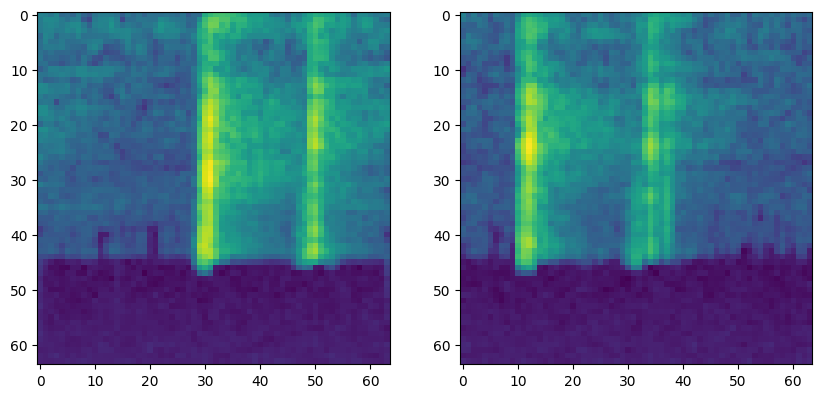

In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(train_set[3][0][0], cmap='viridis')
ax2.imshow(val_set[0][0][0], cmap='viridis')
print(train_set[0][0][0].shape)
ax1.grid(False)
ax2.grid(False)
plt.show()

### CNN Model

In [77]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [78]:
class CNN(nn.Module):
    def __init__(self, num_classes=36):
        super().__init__()

        self.conv1 = ConvBlock(1, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout2d(0.25)

        self.conv2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout2d(0.25)

        self.conv3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout2d(0.3)

        self.conv4 = ConvBlock(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout4 = nn.Dropout2d(0.3)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.pool2(x)
        x = self.dropout2(x)

        x = self.conv3(x)
        x = self.pool3(x)
        x = self.dropout3(x)

        x = self.conv4(x)
        x = self.pool4(x)
        x = self.dropout4(x)

        x = self.global_pool(x)
        x = self.fc(x)

        return x


In [79]:
model = CNN(num_classes=dataset.num_classes())

In [80]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [81]:
def get_device():
    if torch.cuda.is_available():
        try:
            torch.zeros(1).cuda()
            return 'cuda'
        except Exception as e:
            print(f"⚠️  CUDA available but unusable ({e}), falling back to CPU")
    return 'cpu'

device = get_device()

model.apply(init_weights)
model.to(device)

print("Number of parameters: {:,}".format(sum(p.numel() for p in model.parameters())))
print(f"Device: {device}")

summary(model, input_size=(1, 1, 64, 64))


Number of parameters: 4,856,932
Device: cpu


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 36]                   --
├─ConvBlock: 1-1                         [1, 64, 64, 64]           --
│    └─Sequential: 2-1                   [1, 64, 64, 64]           --
│    │    └─Conv2d: 3-1                  [1, 64, 64, 64]           640
│    │    └─BatchNorm2d: 3-2             [1, 64, 64, 64]           128
│    │    └─ReLU: 3-3                    [1, 64, 64, 64]           --
│    │    └─Conv2d: 3-4                  [1, 64, 64, 64]           36,928
│    │    └─BatchNorm2d: 3-5             [1, 64, 64, 64]           128
│    │    └─ReLU: 3-6                    [1, 64, 64, 64]           --
├─MaxPool2d: 1-2                         [1, 64, 32, 32]           --
├─Dropout2d: 1-3                         [1, 64, 32, 32]           --
├─ConvBlock: 1-4                         [1, 128, 32, 32]          --
│    └─Sequential: 2-2                   [1, 128, 32, 32]          --
│    │  

### Training setup

In [82]:
train_dataloader = torch.utils.data.DataLoader(
    train_set,
    batch_size=32,
    shuffle=True
)

val_dataloader = torch.utils.data.DataLoader(
    val_set,
    batch_size=32,
    shuffle=False
)

test_dataloader = torch.utils.data.DataLoader(
    test_set,
    batch_size=32,
    shuffle=False
)

In [83]:
cost = nn.CrossEntropyLoss()

learning_rate = 1e-3
weight_decay = 1e-4
max_epochs = 1200  # Maximum epochs (safety limit)

# Early Stopping Parameters
early_stopping_patience = 50  # Stop if no improvement for 50 epochs
early_stopping_min_delta = 0.001  # Minimum change to qualify as improvement

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

### Training

In [84]:
def plot_results(train_losses, train_accuracies, val_losses, val_accuracies):
    plt.figure(figsize=(12, 4))
    plt.subplot(1,2,1)
    plt.title("Loss")
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.legend(["Training loss", "Validation loss"], loc="best")
    plt.subplot(1,2,2)
    plt.title("Accuracy")
    plt.plot(train_accuracies)
    plt.plot(val_accuracies)
    plt.legend(["Training accuracy", "Validation accuracy"], loc="best")
    plt.show()

In [85]:
def save_model(model, path):
    torch.save(model.state_dict(), path)

class EarlyStopping:
    """Early stopping to stop training when validation loss doesn't improve"""
    def __init__(self, patience=50, min_delta=0.001, mode='min'):
        """
        Args:
            patience: Number of epochs to wait after last improvement
            min_delta: Minimum change in monitored metric to qualify as improvement
            mode: 'min' for loss (lower is better), 'max' for accuracy (higher is better)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.improved = False
        
    def __call__(self, current_score):
        """Check if training should stop"""
        self.improved = False
        
        if self.best_score is None:
            self.best_score = current_score
            self.improved = True
        elif self.mode == 'min':
            if current_score < self.best_score - self.min_delta:
                self.best_score = current_score
                self.counter = 0
                self.improved = True
            else:
                self.counter += 1
        else:  # mode == 'max'
            if current_score > self.best_score + self.min_delta:
                self.best_score = current_score
                self.counter = 0
                self.improved = True
            else:
                self.counter += 1
        
        if self.counter >= self.patience:
            self.early_stop = True
            
        return self.early_stop

🚀 Starting training with early stopping:
   • Max epochs: 1200
   • Early stopping patience: 50 epochs
   • Min delta: 0.001
   • Monitoring: Validation Loss

Epoch [1/1200], Train Loss: 3.7163, Train Acc: 0.0286, Val Loss: 3.5810, Val Acc: 0.0362
  ✓ Best model saved with validation accuracy: 0.0362
Epoch [2/1200], Train Loss: 3.5833, Train Acc: 0.0293, Val Loss: 3.5529, Val Acc: 0.0373
  ✓ Best model saved with validation accuracy: 0.0373
Epoch [3/1200], Train Loss: 3.5749, Train Acc: 0.0328, Val Loss: 3.5600, Val Acc: 0.0381
  ✓ Best model saved with validation accuracy: 0.0381
Epoch [4/1200], Train Loss: 3.5641, Train Acc: 0.0366, Val Loss: 3.5179, Val Acc: 0.0588
  ✓ Best model saved with validation accuracy: 0.0588
Epoch [5/1200], Train Loss: 3.5496, Train Acc: 0.0397, Val Loss: 3.5526, Val Acc: 0.0501
Epoch [6/1200], Train Loss: 3.5262, Train Acc: 0.0421, Val Loss: 3.3393, Val Acc: 0.0603
  ✓ Best model saved with validation accuracy: 0.0603
Epoch [7/1200], Train Loss: 3.4052, T

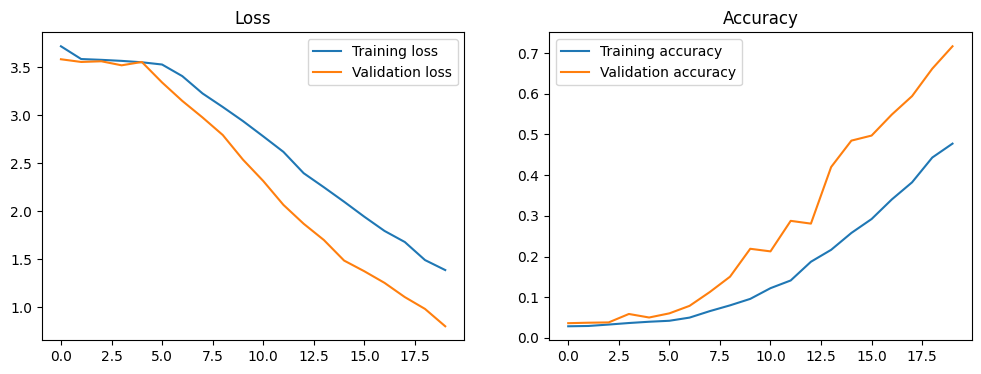

  ✓ Best model saved with validation accuracy: 0.7165
Epoch [21/1200], Train Loss: 1.2842, Train Acc: 0.5212, Val Loss: 0.8341, Val Acc: 0.7169
  ✓ Best model saved with validation accuracy: 0.7169
Epoch [22/1200], Train Loss: 1.1925, Train Acc: 0.5637, Val Loss: 0.6501, Val Acc: 0.7753
  ✓ Best model saved with validation accuracy: 0.7753
Epoch [23/1200], Train Loss: 1.1155, Train Acc: 0.5915, Val Loss: 0.6182, Val Acc: 0.7723
Epoch [24/1200], Train Loss: 1.0027, Train Acc: 0.6333, Val Loss: 0.5779, Val Acc: 0.8089
  ✓ Best model saved with validation accuracy: 0.8089


In [ ]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

# Initialize early stopping
early_stopping = EarlyStopping(patience=early_stopping_patience, 
                                min_delta=early_stopping_min_delta, 
                                mode='min')  # Monitor validation loss

print(f"🚀 Starting training with early stopping:")
print(f"   • Max epochs: {max_epochs}")
print(f"   • Early stopping patience: {early_stopping_patience} epochs")
print(f"   • Min delta: {early_stopping_min_delta}")
print(f"   • Monitoring: Validation Loss\n")

for epoch in range(max_epochs):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0

    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = cost(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        epoch_loss += loss.item()

    train_acc = correct / total
    avg_train_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        val_loss = 0

        for inputs, labels in val_dataloader:
            inputs = inputs.to(device)
            labels = torch.squeeze(labels).to(device)
            outputs = model(inputs)

            loss = cost(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        val_acc = correct / total
        avg_val_loss = val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch + 1}/{max_epochs}], Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if epoch != 0 and (epoch % 20 == 19):
        plot_results(train_losses, train_accuracies, val_losses, val_accuracies)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_model(model, best_model_path)
        print(f"  ✓ Best model saved with validation accuracy: {val_acc:.4f}")
    
    # Early stopping check
    if early_stopping(avg_val_loss):
        print(f"\n🛑 Early stopping triggered after {epoch + 1} epochs")
        print(f"   • No improvement in validation loss for {early_stopping.patience} epochs")
        print(f"   • Best validation loss: {early_stopping.best_score:.4f}")
        print(f"   • Best validation accuracy: {best_val_acc:.4f}")
        break

# Final summary
if not early_stopping.early_stop:
    print(f"\n✅ Training completed - reached maximum epochs ({max_epochs})")
else:
    print(f"\n✅ Training completed - early stopping at epoch {epoch + 1}")
    
print(f"   • Total epochs trained: {len(train_losses)}")
print(f"   • Best validation accuracy: {best_val_acc:.4f}")
print(f"   • Final validation accuracy: {val_accuracies[-1]:.4f}")

In [ ]:
save_model(model, model_path)

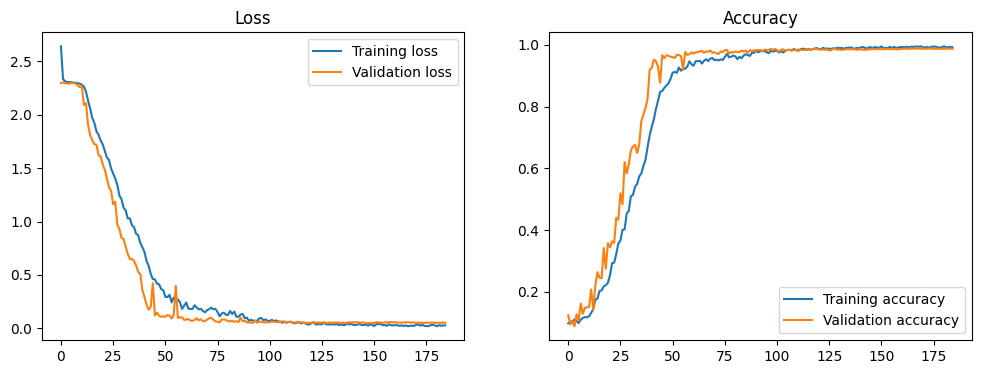


📊 Training Summary:
   • Best validation acc: 0.9878
   • Last validation acc: 0.9868
   • Epochs trained: 185


In [ ]:
# Plot final training results
plot_results(train_losses, train_accuracies, val_losses, val_accuracies)

print(f"\n📊 Training Summary:")
print(f"   • Best validation acc: {max(val_accuracies):.4f}")
print(f"   • Last validation acc: {val_accuracies[-1]:.4f}")
print(f"   • Epochs trained: {len(val_accuracies)}")

---

## 🔧 Fine-Tuning

For fine-tuning a trained model on production/deployment data, use:

**[CNN-FineTuning.ipynb](CNN-FineTuning.ipynb)**

This separate notebook allows you to:
- Load a pre-trained model from this notebook
- Fine-tune on small production datasets  
- Freeze early layers for better performance on small data
- Compare original vs fine-tuned model accuracy

---

### Results

In [ ]:
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

CNN(
  (conv1): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (conv2): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [ ]:
digits = [str(digit) for digit in range(10)]
alphabet = [chr(ascii_code) for ascii_code in range(ord('A'), ord('Z') + 1)]
all_characters = digits + alphabet
label_dict = {i: all_characters[i] for i in range(len(all_characters))}
print(label_dict)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'}


In [ ]:
def predict(data_loader):
    original_labels = []
    predicted_labels = []
    correct = 0
    total = 0

    model.eval()

    for inputs, labels in data_loader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)
        outputs = model(inputs)

        _, predicted = torch.max(outputs.data, 1)

        original_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    prediction_df = pd.DataFrame({
        "predicted_labels": [label_dict[pred] for pred in predicted_labels],
        "true_labels": [label_dict[label] for label in original_labels]
    })

    print(f"Test Accuracy: {correct/total}")
    pd.set_option('display.max_rows', None)
    pd.set_option("display.max_columns", None)
    display(prediction_df.T)

    print(metrics.accuracy_score(original_labels, predicted_labels))
    print(metrics.classification_report(original_labels, predicted_labels))

    return confusion_matrix(original_labels, predicted_labels)

### Test accuracy

In [ ]:
cm = predict(test_dataloader)

Test Accuracy: 0.9835051546391752


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484
predicted_labels,9,2,4,3,8,7,3,7,7,0,4,5,9,0,6,4,5,5,3,5,2,0,6,6,3,6,5,1,0,7,0,6,3,0,4,5,0,2,8,7,4,7,1,5,0,7,9,8,1,8,1,9,9,8,3,9,9,6,8,4,4,5,7,1,6,8,8,8,6,0,0,8,4,5,2,9,6,6,9,2,8,5,1,5,9,9,6,8,6,2,6,8,5,5,9,9,4,5,1,1,3,6,5,1,2,4,2,0,8,1,3,7,0,3,1,9,4,7,5,1,3,6,3,4,3,1,3,3,6,1,1,2,2,6,8,6,3,3,9,3,2,3,6,6,3,3,7,4,4,7,7,4,6,4,9,7,5,5,3,5,3,4,3,9,3,6,7,4,5,5,0,6,7,1,1,3,1,2,8,2,3,3,3,3,2,9,3,3,2,9,5,8,5,1,9,8,0,9,7,0,3,0,7,0,8,1,2,6,4,0,5,7,7,9,0,5,0,5,4,9,8,7,4,4,5,1,4,7,0,5,8,7,5,2,1,0,3,7,3,1,3,8,0,1,4,2,7,6,2,7,7,9,4,8,4,0,9,4,6,4,9,3,2,0,2,4,4,1,6,2,7,5,2,4,7,8,0,6,4,6,9,7,2,9,5,2,7,0,2,9,6,6,0,0,7,7,2,2,9,8,8,4,0,6,8,3,4,6,1,3,0,1,2,9,8,8,7,5,5,6,4,1,2,5,4,8,4,2,9,9,8,0,3,7,2,1,4,2,6,3,0,5,8,0,7,7,7,2,0,2,1,2,9,2,6,8,8,2,9,8,8,7,0,1,5,5,0,3,0,3,6,9,7,6,2,9,6,7,1,6,8,4,4,7,1,3,5,8,2,2,3,8,0,5,5,3,7,6,4,7,1,9,8,1,2,5,6,9,7,8,3,4,9,1,1,2,9,9,3,4,2,9,0,6,5,8,0,0,7,8,1,5,2,9,4,6,5,7,3,0,4,4,1,3,2,6,8,2,1,2,7,0,5,9,2,2,5,5,6,1,9,5,7,3,6,8,5,9,4,0,0,7,6,7,9,0,6,8,5,0,0,4,0,8,5
true_labels,9,2,4,3,8,7,3,7,7,0,4,5,9,0,6,4,5,5,3,5,2,0,6,6,3,6,5,1,0,7,0,6,3,0,4,5,0,2,8,7,4,7,1,5,0,7,9,8,1,8,1,9,9,8,3,9,9,6,8,4,4,5,7,1,6,8,8,8,6,0,0,8,4,5,2,9,6,6,9,2,8,5,1,5,9,9,6,8,6,2,6,8,5,5,9,9,4,5,1,1,3,6,5,1,2,4,2,0,8,1,3,7,0,3,1,9,4,7,5,1,3,6,1,4,3,1,3,3,6,1,1,2,2,6,8,6,3,3,9,3,2,3,6,6,3,3,7,4,4,7,7,4,6,4,9,7,5,5,3,5,3,4,8,9,3,6,7,4,5,5,0,6,7,1,1,3,1,2,8,2,3,3,3,3,2,9,3,3,2,9,5,8,5,9,9,8,0,9,7,0,3,0,7,0,8,1,2,6,4,0,5,7,7,9,0,5,0,5,4,9,8,7,4,4,5,1,4,8,0,5,8,7,5,2,1,0,3,7,3,1,3,8,0,1,4,2,7,6,2,7,7,9,4,8,4,0,9,4,6,4,9,3,2,0,2,4,4,1,6,2,7,5,2,4,7,8,0,6,4,6,9,7,2,9,5,2,7,0,2,9,6,6,0,0,7,7,2,2,9,8,8,4,0,6,8,3,4,6,6,3,0,1,2,9,8,8,7,5,5,6,4,1,2,5,4,8,4,2,9,9,8,0,3,7,2,1,4,2,6,3,0,5,8,0,7,7,7,2,0,2,1,2,9,2,6,8,8,2,9,8,8,7,0,1,5,5,0,3,0,3,6,9,7,6,2,9,6,7,1,6,8,4,4,7,1,3,5,8,2,2,3,8,0,0,5,3,7,6,4,7,1,9,8,1,2,5,6,9,7,8,3,4,9,1,1,2,9,9,3,4,2,9,0,6,5,8,0,0,7,8,1,5,2,9,4,6,5,7,3,0,4,4,1,3,2,6,8,2,1,2,7,0,5,9,2,2,5,5,6,1,9,5,7,3,6,8,5,9,4,0,0,7,6,7,9,0,6,8,3,0,0,4,4,8,5


0.9835051546391752
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        50
           1       0.95      0.97      0.96        40
           2       1.00      1.00      1.00        50
           3       0.96      0.98      0.97        49
           4       1.00      0.98      0.99        49
           5       0.96      1.00      0.98        49
           6       1.00      0.98      0.99        50
           7       0.98      1.00      0.99        50
           8       1.00      0.96      0.98        49
           9       1.00      0.98      0.99        49

    accuracy                           0.98       485
   macro avg       0.98      0.98      0.98       485
weighted avg       0.98      0.98      0.98       485



### Confusion matrix

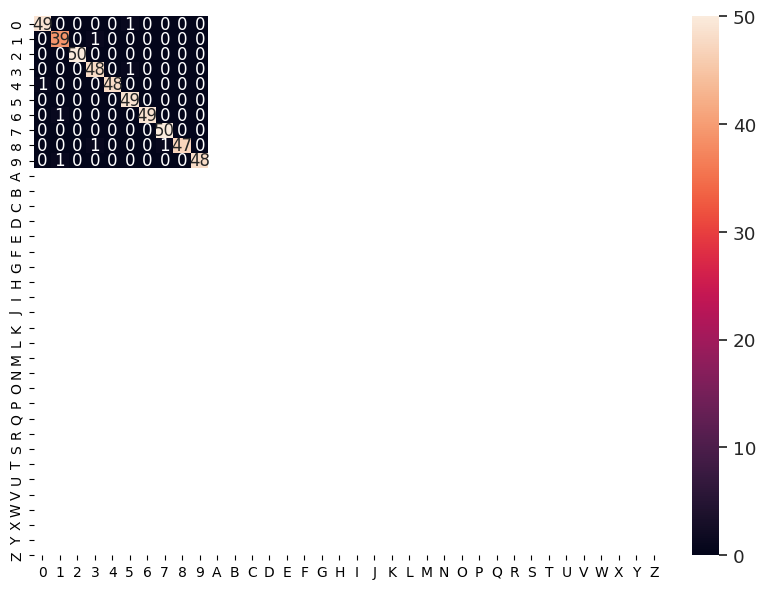

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))
sns.set(font_scale=1.2)
ax = sns.heatmap(cm,
                annot=True,
                fmt='g',
                xticklabels=all_characters,
                yticklabels=all_characters,
                annot_kws={"size": 12}
                )
plt.show()

---

## 🎙️ Gradio Web Interface

Interactive web interface for testing the trained model with real audio recordings or uploaded files.

In [ ]:
import sys
import os
best_model_path = "model/CNN-Best.pkl"
# Add inference module to path
inference_path = os.path.join(os.getcwd(), 'inference')
if inference_path not in sys.path:
    sys.path.insert(0, inference_path)

from app_gradio import create_gradio_interface

# Create the Gradio interface with the best model
interface = create_gradio_interface(model_path=best_model_path)

print("✅ Gradio interface created successfully!")
print(f"   Model: {best_model_path}")

/root/minor/keyboard_sound/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading model from: model/CNN-Best.pkl
Device: CUDA
⚠ Warning: Unknown model type, defaulting to CNN
First 5 keys: ['conv1.conv.0.weight', 'conv1.conv.0.bias', 'conv1.conv.1.weight', 'conv1.conv.1.bias', 'conv1.conv.1.running_mean']
Creating CNN model with 36 classes...
Using alphanumeric labels (0-9, a-z)
Model parameters: 4,856,932
Model test successful - output shape: torch.Size([1, 36])
✓ Model loaded successfully!

✅ Gradio interface created successfully!
   Model: model/CNN-Best.pkl


In [ ]:
# Launch the Gradio interface
# Options:
#   share=True  : Create a public shareable link (requires internet)
#   share=False : Local access only (default)
#   server_port=7860 : Specify a custom port

print("\n🚀 Launching Gradio web interface...")
print("   Once launched, the interface will be available at the URL shown below.")
print("   Use it to test the model with real-time audio recording or file uploads.\n")

# Launch with auto-reload disabled in notebook environment
interface.launch(
    share=True,
    inline=False,  # Display inline in Jupyter notebook
    quiet=True,   # Suppress Gradio logs for cleaner output
)


🚀 Launching Gradio web interface...
   Once launched, the interface will be available at the URL shown below.
   Use it to test the model with real-time audio recording or file uploads.

* Running on public URL: https://7502c3ab217e3896f6.gradio.live


# 🔍 Grad-CAM: Visual Explanation of CNN Predictions

## What is Grad-CAM?

**Grad-CAM (Gradient-weighted Class Activation Mapping)** is a visualization technique that helps us understand which regions of an input image (in our case, a Mel Spectrogram) the CNN model focuses on when making predictions.

### How Grad-CAM Works

1. **Forward Pass**: The input (Mel Spectrogram) is passed through the CNN to get the predicted class
2. **Backward Pass**: Gradients of the predicted class score are computed with respect to the feature maps of the last convolutional layer
3. **Weight Calculation**: These gradients are globally averaged to get importance weights for each feature map
4. **Activation Map**: The weighted sum of feature maps produces a coarse localization map highlighting important regions
5. **Visualization**: The heatmap is upsampled and overlaid on the original spectrogram

### Why Use the Last Convolutional Layer?

The **last convolutional layer** (`conv4` in our model) is ideal because:
- It has the **highest-level semantic information** (understands "what" features are important)
- It still retains **spatial information** (understands "where" those features are)
- Earlier layers capture low-level features (edges, textures) that are less interpretable
- Fully connected layers lose all spatial information

### Why This Matters for Our Project

For keyboard keystroke detection, Grad-CAM helps us verify that the model is:
- ✅ **Focusing on the keystroke burst** in the Mel Spectrogram (the actual key press sound)
- ✅ **Learning meaningful temporal patterns** (when the key was pressed)
- ✅ **Ignoring background noise** and irrelevant regions
- ❌ **NOT overfitting** to dataset artifacts or noise patterns

If Grad-CAM shows the model focusing on random regions or noise, it indicates the model isn't learning the right features.

## Grad-CAM Implementation

In [1]:
# Install required dependency for Grad-CAM
# opencv-python provides the cv2 module for image processing
try:
    import cv2
    print("✅ opencv-python is already installed")
except ImportError:
    print("📦 Installing opencv-python...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python"])
    import cv2
    print("✅ opencv-python installed successfully!")

✅ opencv-python is already installed


In [7]:
import cv2
from matplotlib import cm

class GradCAM:
    """
    Grad-CAM (Gradient-weighted Class Activation Mapping) for PyTorch CNNs
    
    This class generates visual explanations showing which regions of the input
    the model focuses on when making predictions.
    """
    
    def __init__(self, model, target_layer):
        """
        Initialize Grad-CAM
        
        Args:
            model: PyTorch CNN model
            target_layer: The layer to visualize (should be last conv layer)
        """
        self.model = model
        self.target_layer = target_layer
        
        # Storage for gradients and activations
        self.gradients = None
        self.activations = None
        
        # Register hooks to capture gradients and activations
        self.register_hooks()
    
    def register_hooks(self):
        """Register forward and backward hooks on the target layer"""
        
        def forward_hook(module, input, output):
            """Capture activations during forward pass"""
            self.activations = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            """Capture gradients during backward pass"""
            self.gradients = grad_output[0].detach()
        
        # Register the hooks
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)
    
    def generate_cam(self, input_tensor, target_class=None):
        """
        Generate Grad-CAM heatmap for the input
        
        Args:
            input_tensor: Input image tensor (1, C, H, W)
            target_class: Target class index. If None, uses predicted class
            
        Returns:
            cam: Grad-CAM heatmap (H, W) normalized to [0, 1]
            predicted_class: The class used for visualization
            prediction_score: Confidence score for the predicted class
        """
        # Set model to evaluation mode
        self.model.eval()
        
        # Forward pass
        output = self.model(input_tensor)
        
        # Get predicted class if not specified
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        # Get prediction score
        prediction_score = torch.softmax(output, dim=1)[0, target_class].item()
        
        # Zero gradients
        self.model.zero_grad()
        
        # Backward pass for the target class
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1.0
        output.backward(gradient=one_hot, retain_graph=True)
        
        # Calculate weights by global average pooling of gradients
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        
        # Weighted combination of activation maps
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        
        # Apply ReLU to focus on positive influence
        cam = torch.relu(cam)
        
        # Normalize to [0, 1]
        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() != 0:
            cam = cam / cam.max()
        
        return cam, target_class, prediction_score
    
    def generate_visualization(self, input_tensor, original_image, target_class=None, alpha=0.5):
        """
        Generate overlaid visualization of Grad-CAM on original image
        
        Args:
            input_tensor: Input tensor for the model (1, C, H, W)
            original_image: Original image as numpy array (H, W) or (H, W, C)
            target_class: Target class for CAM. If None, uses predicted class
            alpha: Transparency of heatmap overlay (0=transparent, 1=opaque)
            
        Returns:
            cam: Grad-CAM heatmap
            heatmap_overlay: Heatmap overlaid on original image
            predicted_class: Class index used
            prediction_score: Confidence score
        """
        # Generate CAM
        cam, predicted_class, prediction_score = self.generate_cam(input_tensor, target_class)
        
        # Resize CAM to match input image size
        if original_image.ndim == 2:
            h, w = original_image.shape
        else:
            h, w = original_image.shape[:2]
        
        cam_resized = cv2.resize(cam, (w, h))
        
        # Convert CAM to RGB heatmap using jet colormap
        heatmap = cm.jet(cam_resized)[:, :, :3]  # Remove alpha channel
        heatmap = (heatmap * 255).astype(np.uint8)
        
        # Convert original image to RGB if grayscale
        if original_image.ndim == 2:
            original_rgb = cv2.cvtColor((original_image * 255).astype(np.uint8), 
                                        cv2.COLOR_GRAY2RGB)
        else:
            original_rgb = (original_image * 255).astype(np.uint8)
        
        # Create overlay
        heatmap_overlay = cv2.addWeighted(original_rgb, 1-alpha, heatmap, alpha, 0)
        
        return cam_resized, heatmap_overlay, predicted_class, prediction_score

print("✅ GradCAM class implemented successfully!")

✅ GradCAM class implemented successfully!


## Visualization Helper Functions

In [8]:
def plot_gradcam_single(original_spec, cam_heatmap, overlay, predicted_class, 
                        prediction_score, true_label=None, idx_to_label=None):
    """
    Plot Grad-CAM visualization for a single sample
    
    Args:
        original_spec: Original mel spectrogram (H, W)
        cam_heatmap: Grad-CAM heatmap (H, W)
        overlay: Overlay of heatmap on spectrogram
        predicted_class: Predicted class index
        prediction_score: Confidence score
        true_label: True label (optional)
        idx_to_label: Dictionary mapping class index to label string (optional)
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Convert label to character if mapping provided
    if idx_to_label:
        pred_char = idx_to_label.get(predicted_class, str(predicted_class))
        true_char = idx_to_label.get(true_label, str(true_label)) if true_label is not None else None
    else:
        pred_char = str(predicted_class)
        true_char = str(true_label) if true_label is not None else None
    
    # Plot original spectrogram
    axes[0].imshow(original_spec, cmap='viridis', aspect='auto')
    axes[0].set_title('Original Mel Spectrogram', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Frequency')
    axes[0].axis('off')
    
    # Plot Grad-CAM heatmap
    im = axes[1].imshow(cam_heatmap, cmap='jet', aspect='auto')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('Frequency')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Plot overlay
    axes[2].imshow(overlay)
    title = f'Overlay\nPredicted: {pred_char} ({prediction_score:.2%})'
    if true_char is not None:
        title += f'\nTrue: {true_char}'
    axes[2].set_title(title, fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Time')
    axes[2].set_ylabel('Frequency')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()


def plot_gradcam_grid(samples, model, gradcam, idx_to_label=None, n_samples=6):
    """
    Plot Grad-CAM visualizations for multiple samples in a grid
    
    Args:
        samples: List of (spectrogram_tensor, label) tuples
        model: Trained CNN model
        gradcam: GradCAM instance
        idx_to_label: Dictionary mapping class index to label string
        n_samples: Number of samples to visualize
    """
    n_samples = min(n_samples, len(samples))
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5*n_samples))
    
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(n_samples):
        spec_tensor, true_label = samples[i]
        
        # Ensure correct shape (1, 1, H, W)
        if spec_tensor.dim() == 2:
            spec_tensor = spec_tensor.unsqueeze(0).unsqueeze(0)
        elif spec_tensor.dim() == 3:
            spec_tensor = spec_tensor.unsqueeze(0)
        
        # Get original spectrogram for visualization
        original_spec = spec_tensor.squeeze().cpu().numpy()
        
        # Generate Grad-CAM
        cam, predicted_class, prediction_score = gradcam.generate_cam(spec_tensor.to(device))
        
        # Resize CAM to match spectrogram
        cam_resized = cv2.resize(cam, (original_spec.shape[1], original_spec.shape[0]))
        
        # Create overlay
        heatmap = cm.jet(cam_resized)[:, :, :3]
        heatmap = (heatmap * 255).astype(np.uint8)
        original_rgb = cv2.cvtColor((original_spec * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        overlay = cv2.addWeighted(original_rgb, 0.5, heatmap, 0.5, 0)
        
        # Convert labels to characters
        if idx_to_label:
            pred_char = idx_to_label.get(predicted_class, str(predicted_class))
            true_char = idx_to_label.get(true_label.item() if torch.is_tensor(true_label) else true_label, '?')
        else:
            pred_char = str(predicted_class)
            true_char = str(true_label.item() if torch.is_tensor(true_label) else true_label)
        
        # Plot original spectrogram
        axes[i, 0].imshow(original_spec, cmap='viridis', aspect='auto')
        if i == 0:
            axes[i, 0].set_title('Original Mel Spectrogram', fontsize=12, fontweight='bold')
        axes[i, 0].set_ylabel(f'Sample {i+1}', fontsize=10)
        axes[i, 0].axis('off')
        
        # Plot Grad-CAM heatmap
        axes[i, 1].imshow(cam_resized, cmap='jet', aspect='auto')
        if i == 0:
            axes[i, 1].set_title('Grad-CAM Heatmap', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
        
        # Plot overlay
        axes[i, 2].imshow(overlay)
        if i == 0:
            axes[i, 2].set_title('Overlay + Prediction', fontsize=12, fontweight='bold')
        
        # Add prediction info
        correct = pred_char == true_char
        color = 'green' if correct else 'red'
        axes[i, 2].text(0.5, -0.1, f'Pred: {pred_char} ({prediction_score:.1%}) | True: {true_char}', 
                       transform=axes[i, 2].transAxes, ha='center', fontsize=10,
                       color=color, fontweight='bold')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

print("✅ Visualization helper functions created!")

✅ Visualization helper functions created!


## Initialize Grad-CAM with Trained Model

In [4]:
# Quick setup: Import required variables if running cells out of order
# This cell ensures all dependencies are available for Grad-CAM analysis

# Check if CNN class is defined
if 'CNN' not in dir():
    print("⚠️  CNN class not found. You need to run cell 29 (define CNN architecture) first!")
    print("   Go to cell 29 (around line 729) and execute it.")
    
# Check if dataset is defined  
if 'dataset' not in dir():
    print("⚠️  Dataset not found. You need to run cell 12 (dataset loading) first!")
    print("   Go to cell 12 (around line 407) and execute it.")

# Check if device is defined
if 'device' not in dir():
    print("⚠️  Device not found. You need to run cell 32 (device detection) first!")
    print("   Go to cell 32 (around line 796) and execute it.")
    
# Check if best_model_path exists (from training)
if 'best_model_path' not in dir():
    print("⚠️  best_model_path not found. Using default path.")
    print("   If you've trained the model, run the training cells to set this variable.")
    best_model_path = "best_model.pth"  # Default fallback
    
# Summary
if all(var in dir() for var in ['CNN', 'dataset', 'device', 'best_model_path']):
    print("✅ All required variables are defined! Ready to initialize Grad-CAM.")
else:
    print("\n❌ Missing required variables. Please run the cells mentioned above first.")

⚠️  CNN class not found. You need to run cell 29 (define CNN architecture) first!
   Go to cell 29 (around line 729) and execute it.
⚠️  Dataset not found. You need to run cell 12 (dataset loading) first!
   Go to cell 12 (around line 407) and execute it.
⚠️  Device not found. You need to run cell 32 (device detection) first!
   Go to cell 32 (around line 796) and execute it.
⚠️  best_model_path not found. Using default path.
   If you've trained the model, run the training cells to set this variable.

❌ Missing required variables. Please run the cells mentioned above first.


In [6]:
# 🚀 STANDALONE GRAD-CAM LOADER
# Run this cell to load everything needed for Grad-CAM visualization
# No need to run previous cells!

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from pathlib import Path

print("="*70)
print(" "*15 + "🚀 LOADING GRAD-CAM DEPENDENCIES")
print("="*70)

# ========== 1. DEFINE CNN CLASS ==========
print("\n1️⃣  Defining CNN architecture...")

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class CNN(nn.Module):
    def __init__(self, num_classes=36):
        super().__init__()

        self.conv1 = ConvBlock(1, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout2d(0.25)

        self.conv2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout2d(0.25)

        self.conv3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout2d(0.3)

        self.conv4 = ConvBlock(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout4 = nn.Dropout2d(0.3)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.pool2(x)
        x = self.dropout2(x)

        x = self.conv3(x)
        x = self.pool3(x)
        x = self.dropout3(x)

        x = self.conv4(x)
        x = self.pool4(x)
        x = self.dropout4(x)

        x = self.global_pool(x)
        x = self.fc(x)

        return x

print("   ✅ CNN architecture defined")

# ========== 2. SET DEVICE ==========
print("\n2️⃣  Setting up device...")
try:
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"   ✅ Using CUDA GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device('cpu')
        print("   ✅ Using CPU")
except:
    device = torch.device('cpu')
    print("   ✅ Using CPU (CUDA unavailable)")

# ========== 3. FIND AND LOAD MODEL ==========
print("\n3️⃣  Finding trained model...")

# Search for model files
model_search_paths = [
    "model/CNN-Best-alphanum-400.pkl",
    "model/CNN-Final-alphanum-400.pkl",
    "model/CNN-Best.pkl",
    "model/CNN-Final.pkl",
]

# Try to find first available model
best_model_path = None
for path in model_search_paths:
    if os.path.exists(path):
        best_model_path = path
        break

if best_model_path is None:
    # Search all .pkl files in model directory
    model_dir = Path("model")
    if model_dir.exists():
        pkl_files = list(model_dir.glob("CNN*.pkl"))
        if pkl_files:
            best_model_path = str(pkl_files[0])

if best_model_path is None:
    print("   ❌ No model file found!")
    print("   Please train the model first or specify the path.")
    raise FileNotFoundError("No trained model found")

print(f"   ✅ Found model: {best_model_path}")

# Load model
print("\n4️⃣  Loading model weights...")
try:
    # Load state dict to check number of classes
    state_dict = torch.load(best_model_path, map_location=device)
    
    # Determine number of classes from fc.7 layer (last layer in Sequential)
    if 'fc.7.weight' in state_dict:
        num_classes = state_dict['fc.7.weight'].shape[0]
    else:
        num_classes = 36  # Default
    
    print(f"   Detected {num_classes} output classes")
    
    # Create model and load weights
    model_gradcam = CNN(num_classes=num_classes).to(device)
    model_gradcam.load_state_dict(state_dict)
    model_gradcam.eval()
    
    print(f"   ✅ Model loaded successfully!")
    print(f"   Parameters: {sum(p.numel() for p in model_gradcam.parameters()):,}")
except Exception as e:
    print(f"   ❌ Error loading model: {e}")
    raise

# ========== 5. CREATE LABEL MAPPING ==========
print("\n5️⃣  Creating label mapping...")  

if num_classes == 36:
    # Alphanumeric: 0-9, a-z
    chars = [str(i) for i in range(10)] + [chr(ord('a') + i) for i in range(26)]
    idx_to_label = {i: chars[i] for i in range(36)}
    print(f"   ✅ Alphanumeric labels (0-9, a-z)")
elif num_classes == 26:
    # Alphabetic only: a-z
    chars = [chr(ord('a') + i) for i in range(26)]
    idx_to_label = {i: chars[i] for i in range(26)}
    print(f"   ✅ Alphabetic labels (a-z)")
elif num_classes == 10:
    # Numeric only: 0-9
    chars = [str(i) for i in range(10)]
    idx_to_label = {i: chars[i] for i in range(10)}
    print(f"   ✅ Numeric labels (0-9)")
else:
    # Generic labels
    idx_to_label = {i: f"class_{i}" for i in range(num_classes)}
    print(f"   ✅ Generic labels for {num_classes} classes")

print(f"   Sample mappings: {dict(list(idx_to_label.items())[:10])}")

# ========== 6. LOAD TEST DATASET (OPTIONAL) ==========
print("\n6️⃣  Loading test dataset...")  

try:
    # Try to load existing dataset (if available from previous cells)
    if 'test_set' in dir() and test_set is not None:
        print(f"   ✅ Using existing test_set with {len(test_set)} samples")
    else:
        # Try to load a small test dataset
        import torchaudio
        from torch.utils.data import Dataset
        
        data_paths = [
            "Data/segmented/alphanum-400",
            "Data/segmented/alphanum-soft-100",
            "Data/segmented/num-large",
        ]
        
        dataset = None
        for data_path in data_paths:
            if os.path.exists(data_path):
                print(f"   Loading from: {data_path}")
                # Use AudioDataset class if available, otherwise skip
                if 'AudioDataset' in dir():
                    dataset = AudioDataset(data_path, None)
                    test_set = dataset
                    print(f"   ✅ Loaded {len(dataset)} samples")
                    break
        
        if dataset is None:
            print("   ⚠️  No dataset loaded (optional for single-image visualization)")
            test_set = None
except Exception as e:
    print(f"   ⚠️  Could not load dataset: {e}")
    print("   You can still use Grad-CAM with individual spectrograms")
    test_set = None
    dataset = None

print("\n" + "="*70)
print(" "*20 + "✅ ALL READY FOR GRAD-CAM!")
print("="*70)
print(f"\n📋 Summary:")
print(f"   • Model: {best_model_path}")
print(f"   • Classes: {num_classes}")
print(f"   • Device: {device}")
print(f"   • Test samples: {len(test_set) if test_set else 'N/A (use manual spectrograms)'}")
print(f"\n🎯 You can now run the Grad-CAM visualization cells below!")
print("="*70)

               🚀 LOADING GRAD-CAM DEPENDENCIES

1️⃣  Defining CNN architecture...
   ✅ CNN architecture defined

2️⃣  Setting up device...
   ✅ Using CPU

3️⃣  Finding trained model...
   ✅ Found model: model/CNN-Best-alphanum-400.pkl

4️⃣  Loading model weights...
   Detected 36 output classes
   ✅ Model loaded successfully!
   Parameters: 4,856,932

5️⃣  Creating label mapping...
   ✅ Alphanumeric labels (0-9, a-z)
   Sample mappings: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}

6️⃣  Loading test dataset...
   Loading from: Data/segmented/alphanum-400
   Loading from: Data/segmented/alphanum-soft-100
   Loading from: Data/segmented/num-large
   ⚠️  No dataset loaded (optional for single-image visualization)

                    ✅ ALL READY FOR GRAD-CAM!

📋 Summary:
   • Model: model/CNN-Best-alphanum-400.pkl
   • Classes: 36
   • Device: cpu
   • Test samples: N/A (use manual spectrograms)

🎯 You can now run the Grad-CAM visualization cells below!

In [10]:
# Initialize Grad-CAM targeting the last convolutional layer (conv4)
# conv4 is the last convolutional block before pooling and fully connected layers
gradcam = GradCAM(model_gradcam, target_layer=model_gradcam.conv4)

print("\n✅ Grad-CAM initialized successfully!")
print(f"   Target layer: conv4 (last convolutional block)")
print(f"   Device: {device}")
print(f"   Model parameters: {sum(p.numel() for p in model_gradcam.parameters()):,}")
print(f"   Ready to visualize model predictions!")


✅ Grad-CAM initialized successfully!
   Target layer: conv4 (last convolutional block)
   Device: cpu
   Model parameters: 4,856,932
   Ready to visualize model predictions!


In [14]:
# Create label mapping (index -> character)
# This assumes your dataset has alphanumeric labels (0-9, a-z)
idx_to_label = {}

# Create reverse mapping from the dataset's label_map
if hasattr(dataset, 'label_map'):
    for label_str, idx in dataset.label_map.items():
        idx_to_label[idx] = label_str
    print(f"✅ Label mapping created: {len(idx_to_label)} classes")
    print(f"   Sample mappings: {dict(list(idx_to_label.items())[:10])}")
else:
    # Fallback: create default alphanumeric mapping
    chars = [str(i) for i in range(10)] + [chr(ord('a') + i) for i in range(26)]
    idx_to_label = {i: chars[i] for i in range(len(chars))}
    print(f"✅ Default label mapping created: {len(idx_to_label)} classes")

✅ Label mapping created: 36 classes
   Sample mappings: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}


In [22]:
# Load test dataset for visualization with PROPER TRANSFORMS
print("📂 Loading test dataset for Grad-CAM visualization...")

# Define the same transforms used during training
import torchaudio
import torch.nn.functional as F
from torchvision.transforms import Compose, ToTensor

sample_rate = 44100
to_mel_spectrogram = torchaudio.transforms.MelSpectrogram(
    sample_rate=sample_rate, 
    n_mels=64, 
    hop_length=300, 
    n_fft=2048, 
    win_length=1024
)
mel_spectrogram_to_numpy = lambda spectrogram: spectrogram.clamp(min=1e-9).log2()[0,:,:].numpy()

# Add resize function to ensure 64x64 shape
def resize_to_64x64(spec_tensor):
    """Resize spectrogram tensor to 64x64"""
    if spec_tensor.dim() == 2:
        spec_tensor = spec_tensor.unsqueeze(0).unsqueeze(0)  # Add batch and channel dims
    elif spec_tensor.dim() == 3:
        spec_tensor = spec_tensor.unsqueeze(0)  # Add batch dim
    
    # Resize to 64x64
    resized = F.interpolate(spec_tensor, size=(64, 64), mode='bilinear', align_corners=False)
    return resized.squeeze(0)  # Remove batch dim, keep (C, H, W)

transforms = Compose([to_mel_spectrogram, mel_spectrogram_to_numpy, ToTensor(), resize_to_64x64])

data_path = "Data/segmented/alphanum-400"

if os.path.exists(data_path):
    # Load dataset WITH transforms (critical for proper shape!)
    dataset = AudioDataset(data_path, transform=transforms)
    
    # Use all data as test set for visualization purposes
    test_set = dataset
    
    print(f"✅ Loaded {len(test_set)} test samples")
    print(f"   Classes: {dataset.num_classes()}")
    print(f"   Data path: {data_path}")
    print(f"   Spectrogram shape will be: (1, 64, 64) after transforms")
else:
    print(f"❌ Test data path not found: {data_path}")

📂 Loading test dataset for Grad-CAM visualization...
✅ Loaded 13200 test samples
   Classes: 36
   Data path: Data/segmented/alphanum-400
   Spectrogram shape will be: (1, 64, 64) after transforms


## Visualize Grad-CAM on Test Samples

Now let's visualize Grad-CAM for individual test samples to see which regions of the Mel Spectrogram the model focuses on.

Analyzing sample 0...
  True label: 0
  Spectrogram shape: torch.Size([1, 64, 64])

📊 Prediction Results:
  Predicted: 0 (confidence: 94.36%)
  True label: 0
  Correct: ✅ Yes


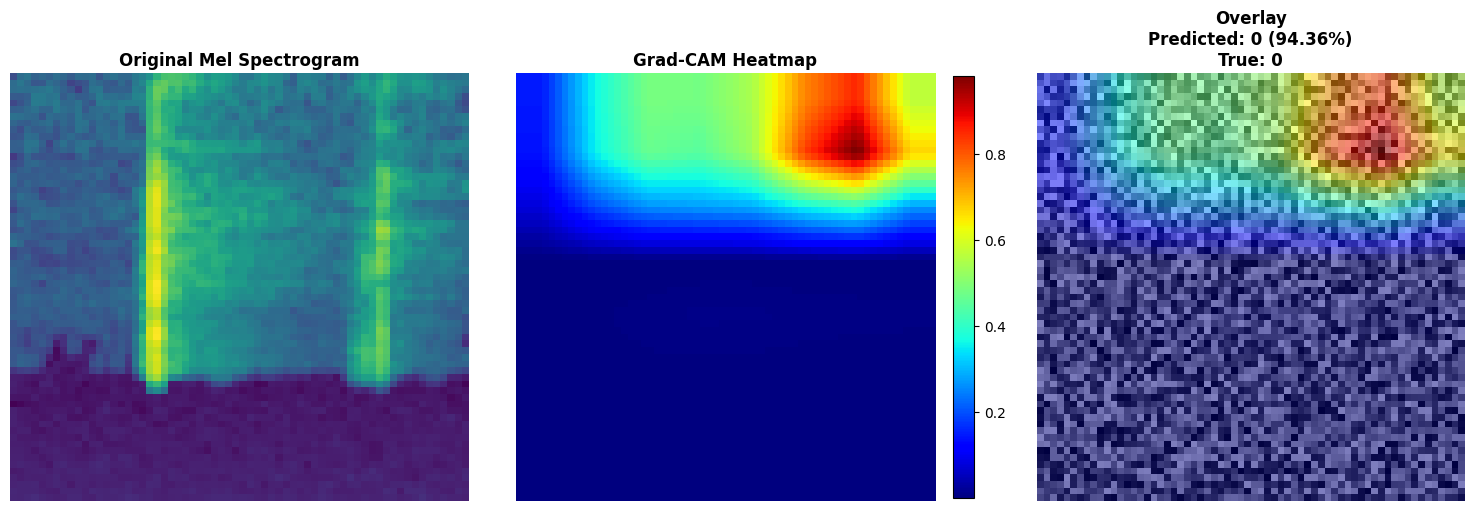

In [24]:
# Select a test sample (you can change the index to visualize different samples)
sample_idx = 0
spec_tensor, true_label = test_set[sample_idx]

print(f"Analyzing sample {sample_idx}...")
print(f"  True label: {idx_to_label.get(true_label.item(), true_label.item())}")
print(f"  Spectrogram shape: {spec_tensor.shape}")

# Ensure correct shape (1, 1, H, W) for model input
if spec_tensor.dim() == 2:
    input_tensor = spec_tensor.unsqueeze(0).unsqueeze(0).to(device)
elif spec_tensor.dim() == 3:
    input_tensor = spec_tensor.unsqueeze(0).to(device)
else:
    input_tensor = spec_tensor.to(device)

# Get original spectrogram for visualization
original_spec = spec_tensor.squeeze().cpu().numpy()

# Generate Grad-CAM visualization
cam, heatmap_overlay, predicted_class, prediction_score = gradcam.generate_visualization(
    input_tensor, 
    original_spec,
    alpha=0.5
)

# Display results
print(f"\n📊 Prediction Results:")
print(f"  Predicted: {idx_to_label.get(predicted_class, predicted_class)} (confidence: {prediction_score:.2%})")
print(f"  True label: {idx_to_label.get(true_label.item(), true_label.item())}")
print(f"  Correct: {'✅ Yes' if predicted_class == true_label.item() else '❌ No'}")

# Plot visualization
plot_gradcam_single(
    original_spec, 
    cam, 
    heatmap_overlay, 
    predicted_class, 
    prediction_score,
    true_label=true_label.item(),
    idx_to_label=idx_to_label
)

## Visualize Multiple Samples in a Grid

Let's visualize Grad-CAM for multiple test samples at once to compare how the model focuses on different keystroke patterns.

Visualizing Grad-CAM for 6 test samples...


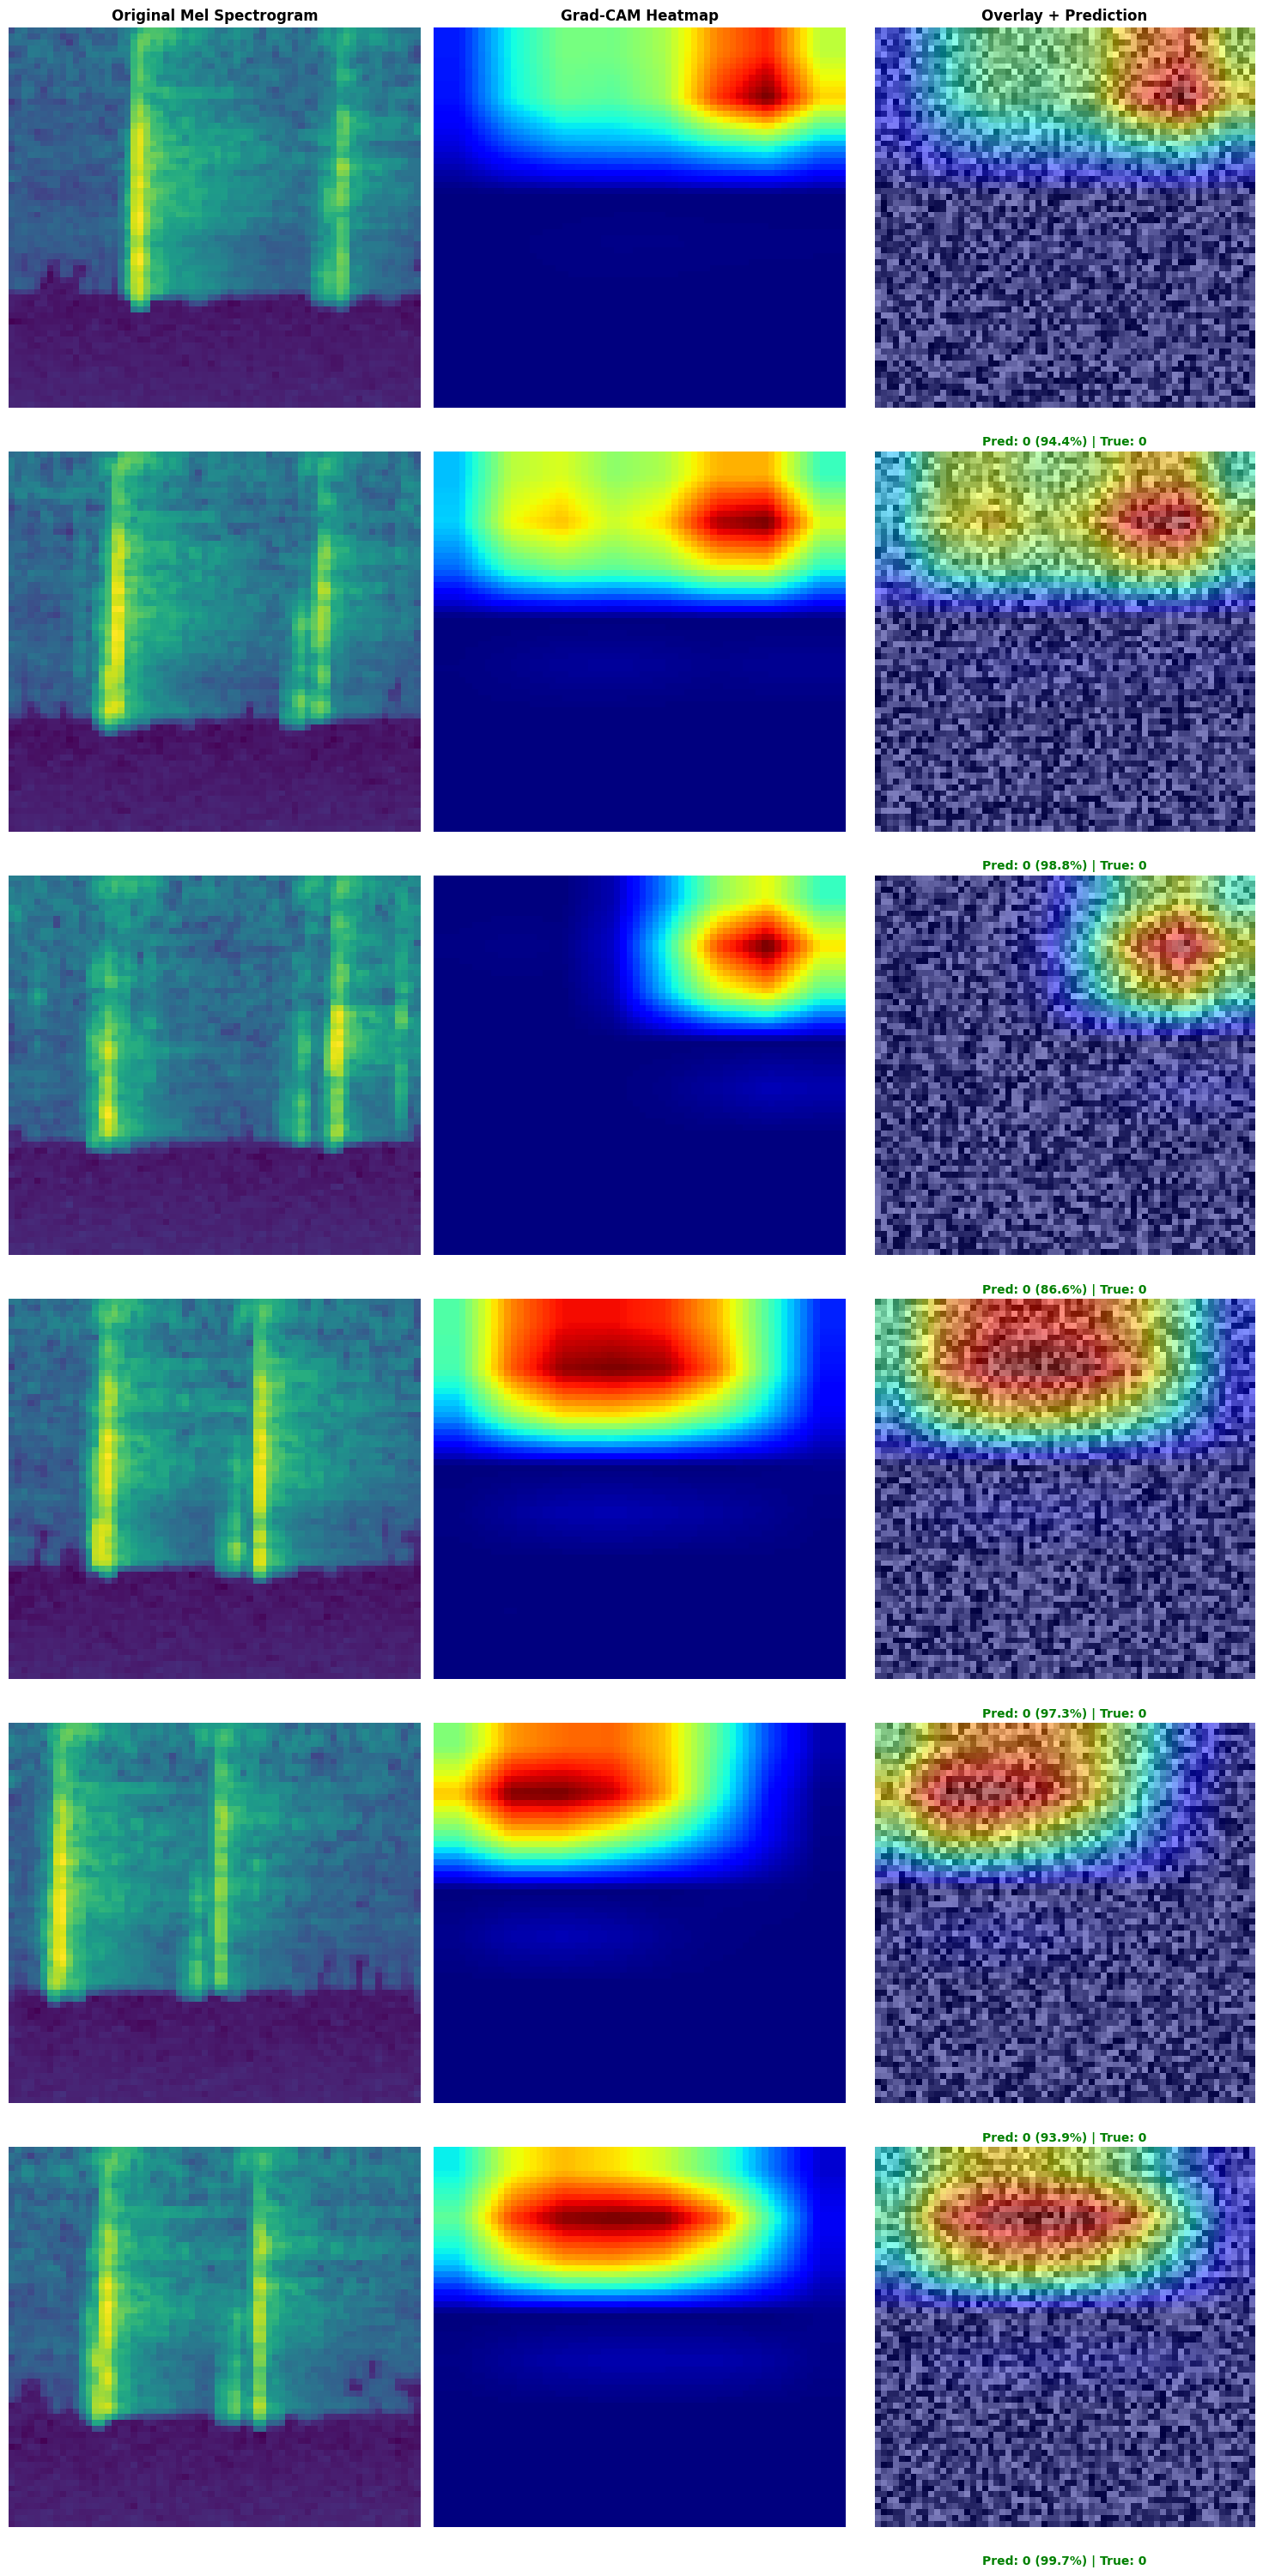

In [25]:
# Visualize multiple samples
n_samples = 6  # Change this to visualize more or fewer samples

# Collect samples from test set
test_samples = [test_set[i] for i in range(min(n_samples, len(test_set)))]

print(f"Visualizing Grad-CAM for {len(test_samples)} test samples...")

# Plot grid visualization
plot_gradcam_grid(
    test_samples, 
    model_gradcam, 
    gradcam, 
    idx_to_label=idx_to_label,
    n_samples=n_samples
)

## Compare Correct vs Incorrect Predictions

Let's specifically look at samples where the model made correct predictions vs incorrect predictions to understand what the model is learning.

🔍 Analyzing test set to find correct and incorrect predictions...
✅ Found 99 correct predictions and 1 incorrect predictions

📊 Grad-CAM for CORRECT Predictions:


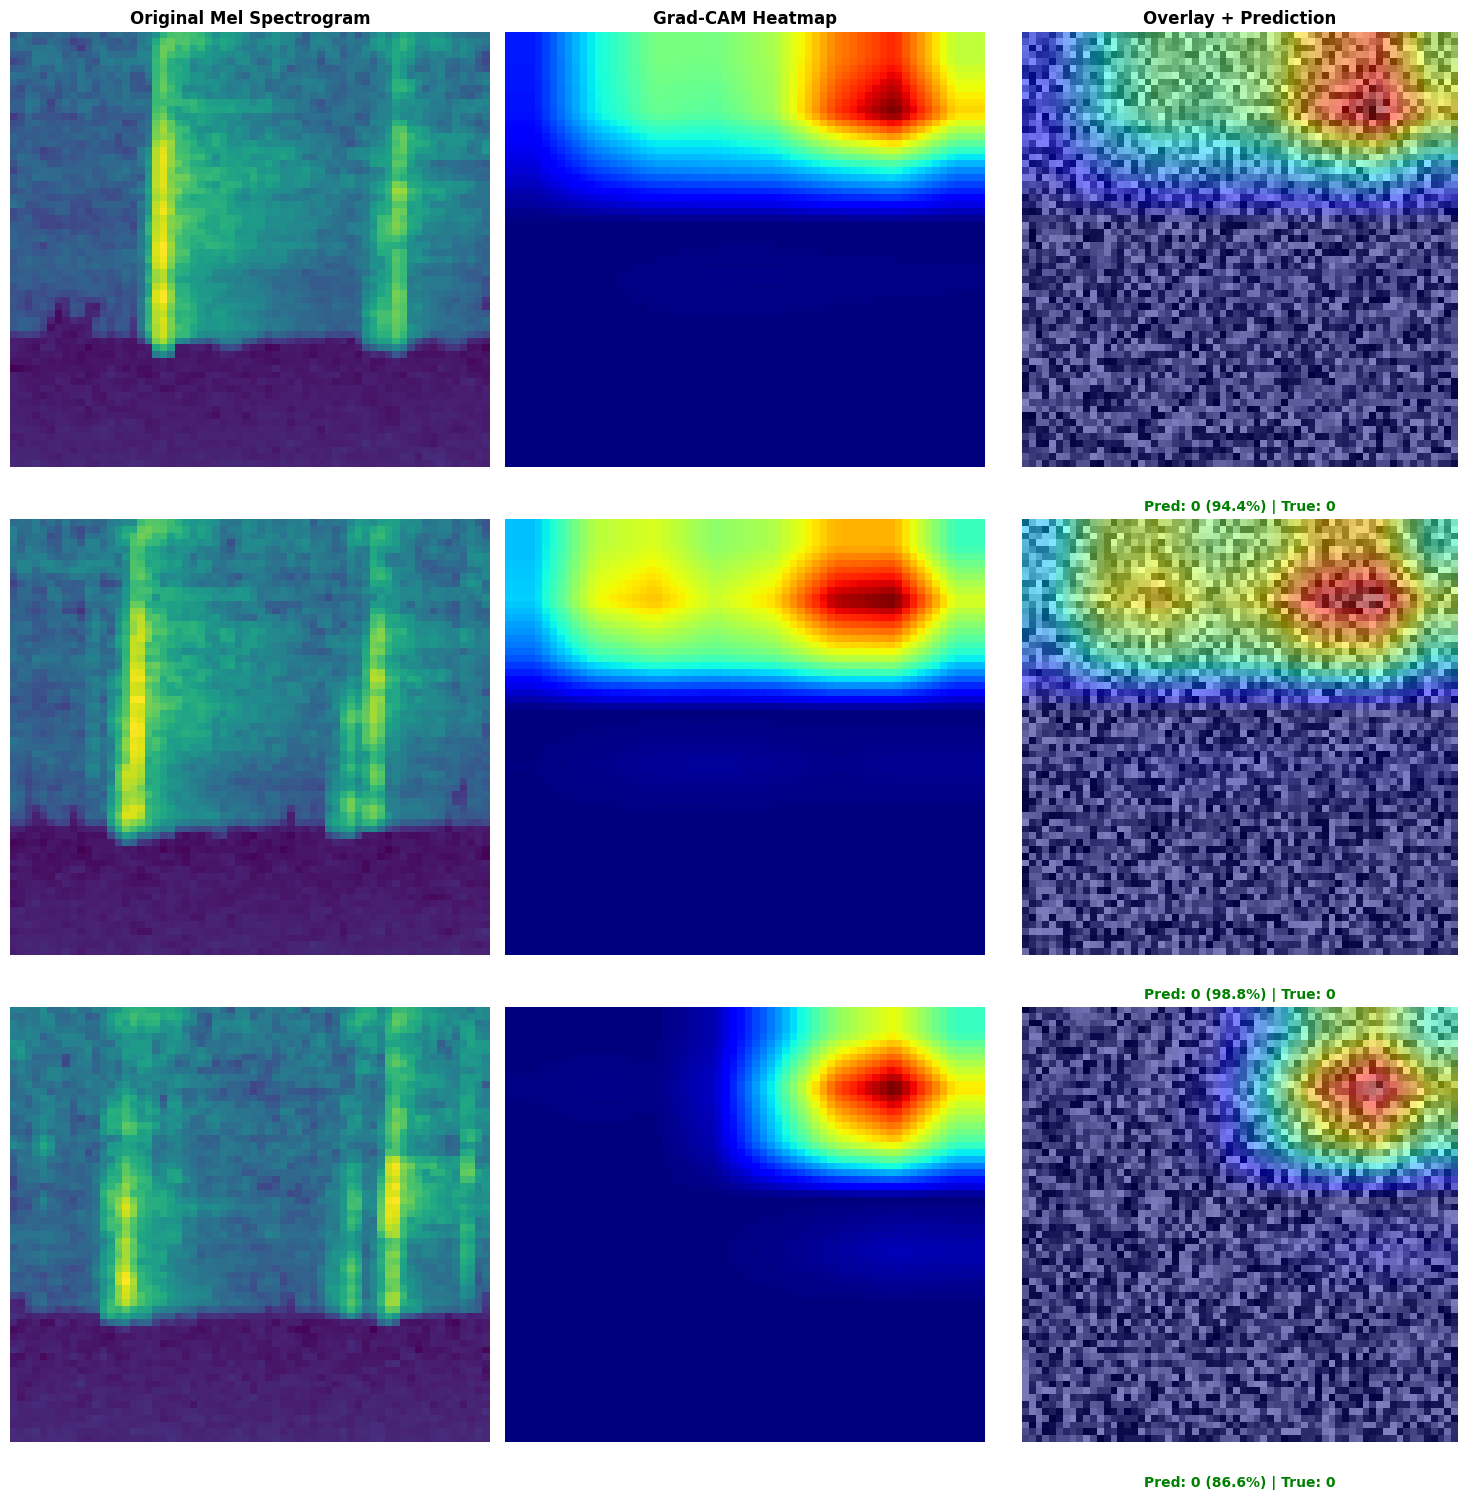


📊 Grad-CAM for INCORRECT Predictions:


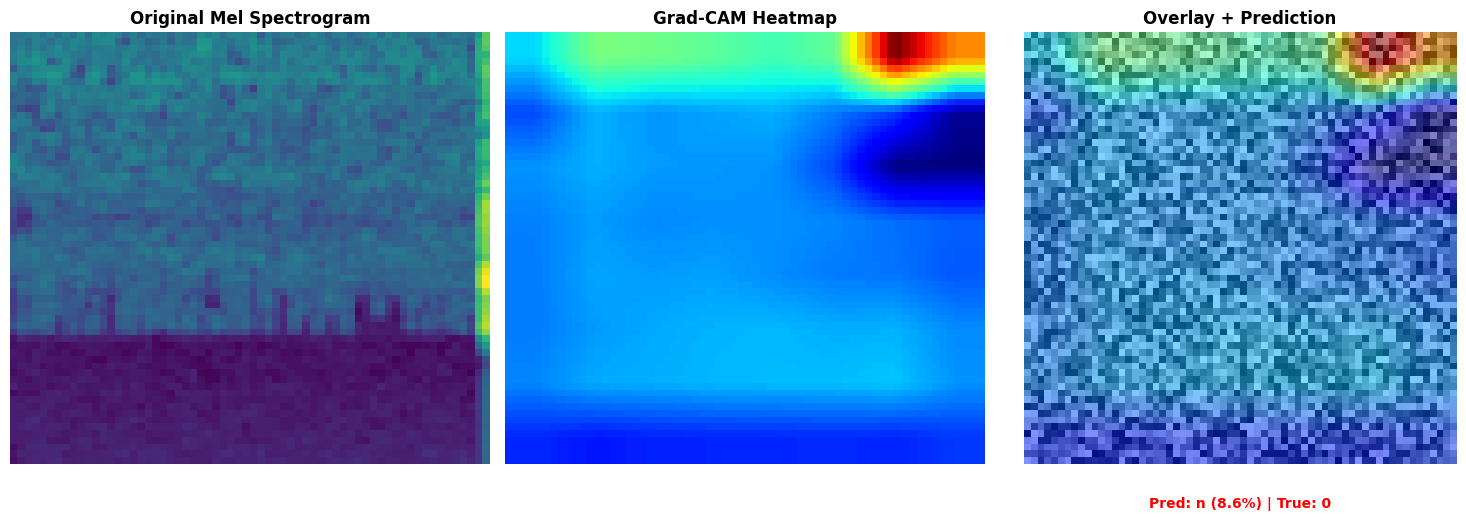

In [26]:
# Find correct and incorrect predictions
correct_samples = []
incorrect_samples = []

print("🔍 Analyzing test set to find correct and incorrect predictions...")

model_gradcam.eval()
with torch.no_grad():
    for i in range(min(100, len(test_set))):  # Check first 100 samples
        spec_tensor, true_label = test_set[i]
        
        # Prepare input
        if spec_tensor.dim() == 2:
            input_tensor = spec_tensor.unsqueeze(0).unsqueeze(0).to(device)
        elif spec_tensor.dim() == 3:
            input_tensor = spec_tensor.unsqueeze(0).to(device)
        else:
            input_tensor = spec_tensor.to(device)
        
        # Get prediction
        output = model_gradcam(input_tensor)
        predicted_class = output.argmax(dim=1).item()
        
        # Store sample
        if predicted_class == true_label.item():
            correct_samples.append((spec_tensor, true_label))
        else:
            incorrect_samples.append((spec_tensor, true_label))
        
        # Stop when we have enough samples
        if len(correct_samples) >= 3 and len(incorrect_samples) >= 3:
            break

print(f"✅ Found {len(correct_samples)} correct predictions and {len(incorrect_samples)} incorrect predictions")

# Visualize correct predictions
if len(correct_samples) > 0:
    print("\n📊 Grad-CAM for CORRECT Predictions:")
    plot_gradcam_grid(correct_samples[:3], model_gradcam, gradcam, idx_to_label=idx_to_label, n_samples=min(3, len(correct_samples)))

# Visualize incorrect predictions
if len(incorrect_samples) > 0:
    print("\n📊 Grad-CAM for INCORRECT Predictions:")
    plot_gradcam_grid(incorrect_samples[:3], model_gradcam, gradcam, idx_to_label=idx_to_label, n_samples=min(3, len(incorrect_samples)))

## Analyzing Specific Keys (Optional)

You can also analyze how the model focuses on specific keys by filtering samples by label.

🔍 Collecting samples for keys: ['a', 'e', '5', '9']...

📊 Grad-CAM Analysis for Key: 'A'


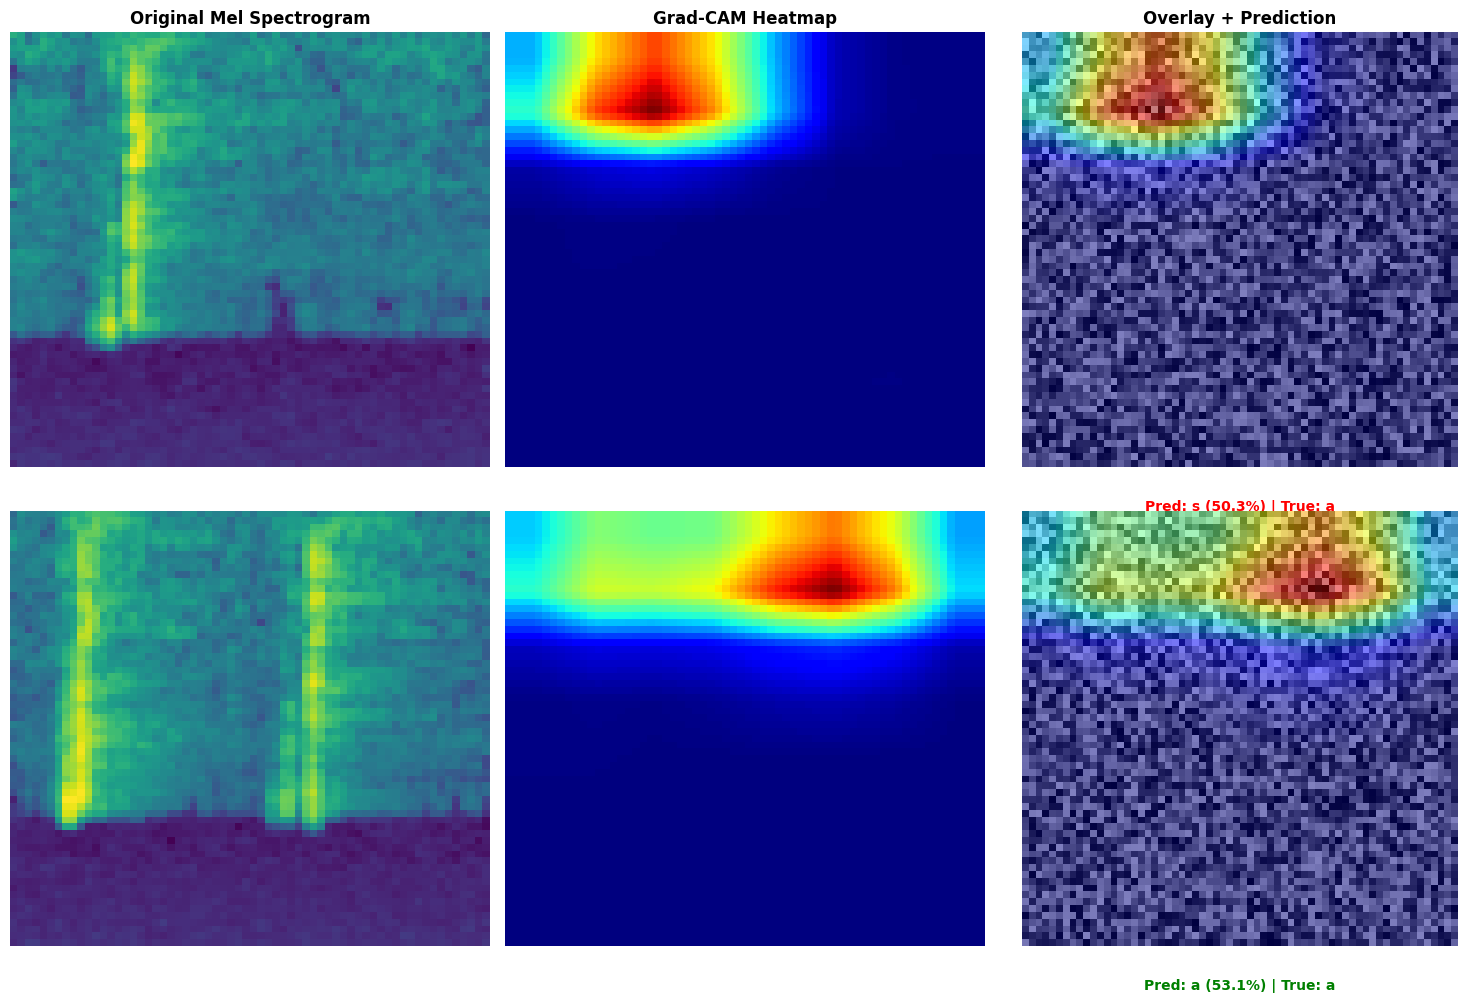


📊 Grad-CAM Analysis for Key: 'E'


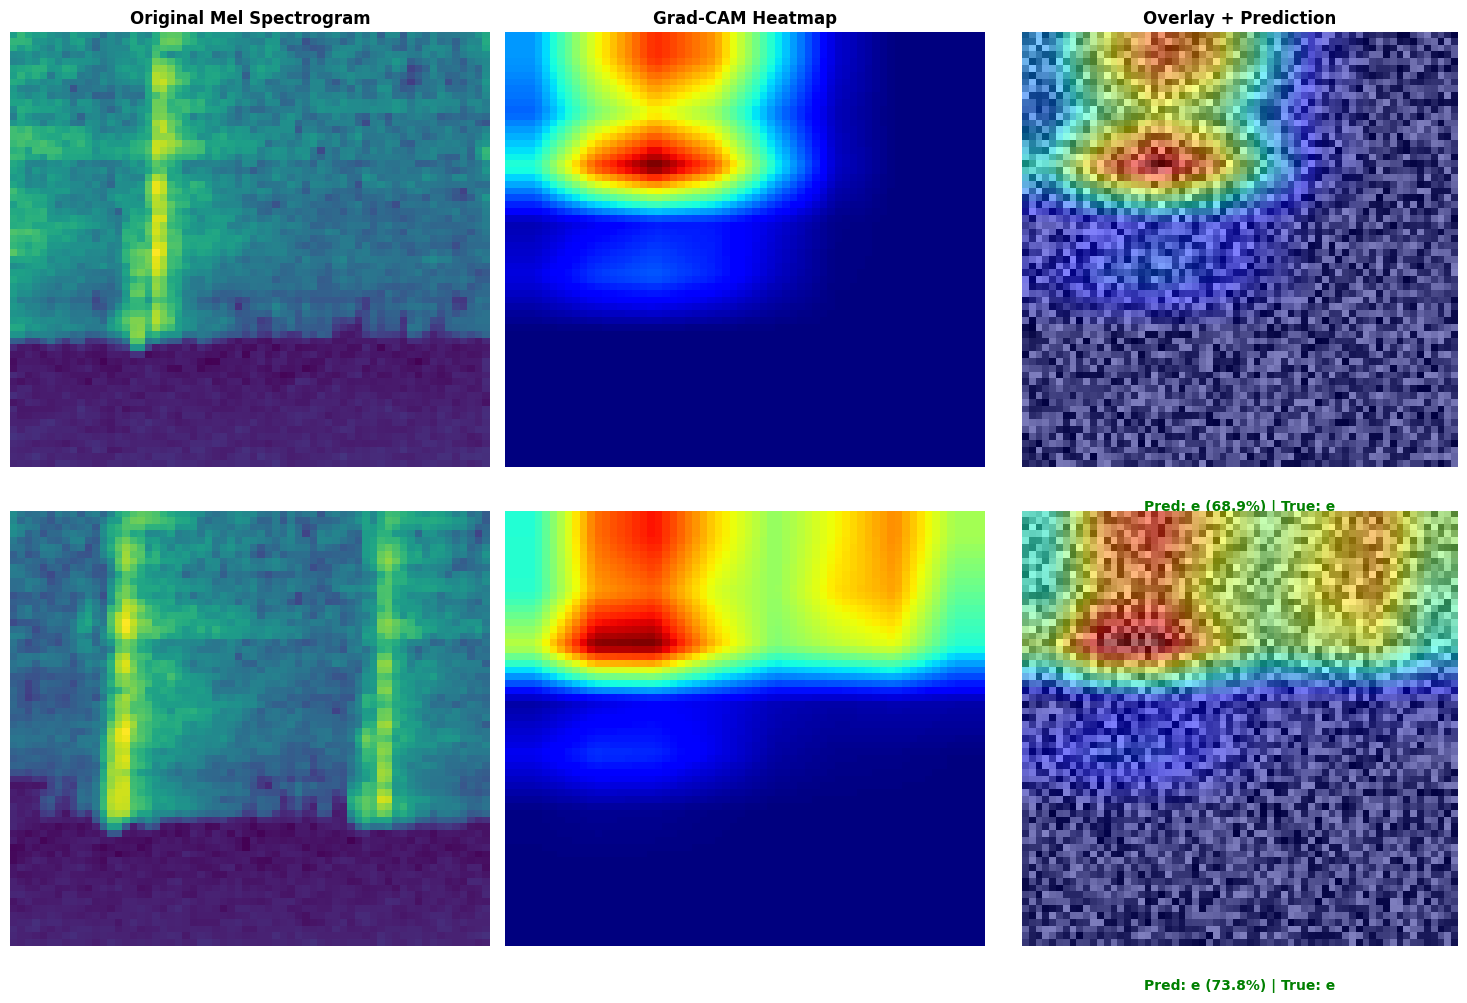


📊 Grad-CAM Analysis for Key: '5'


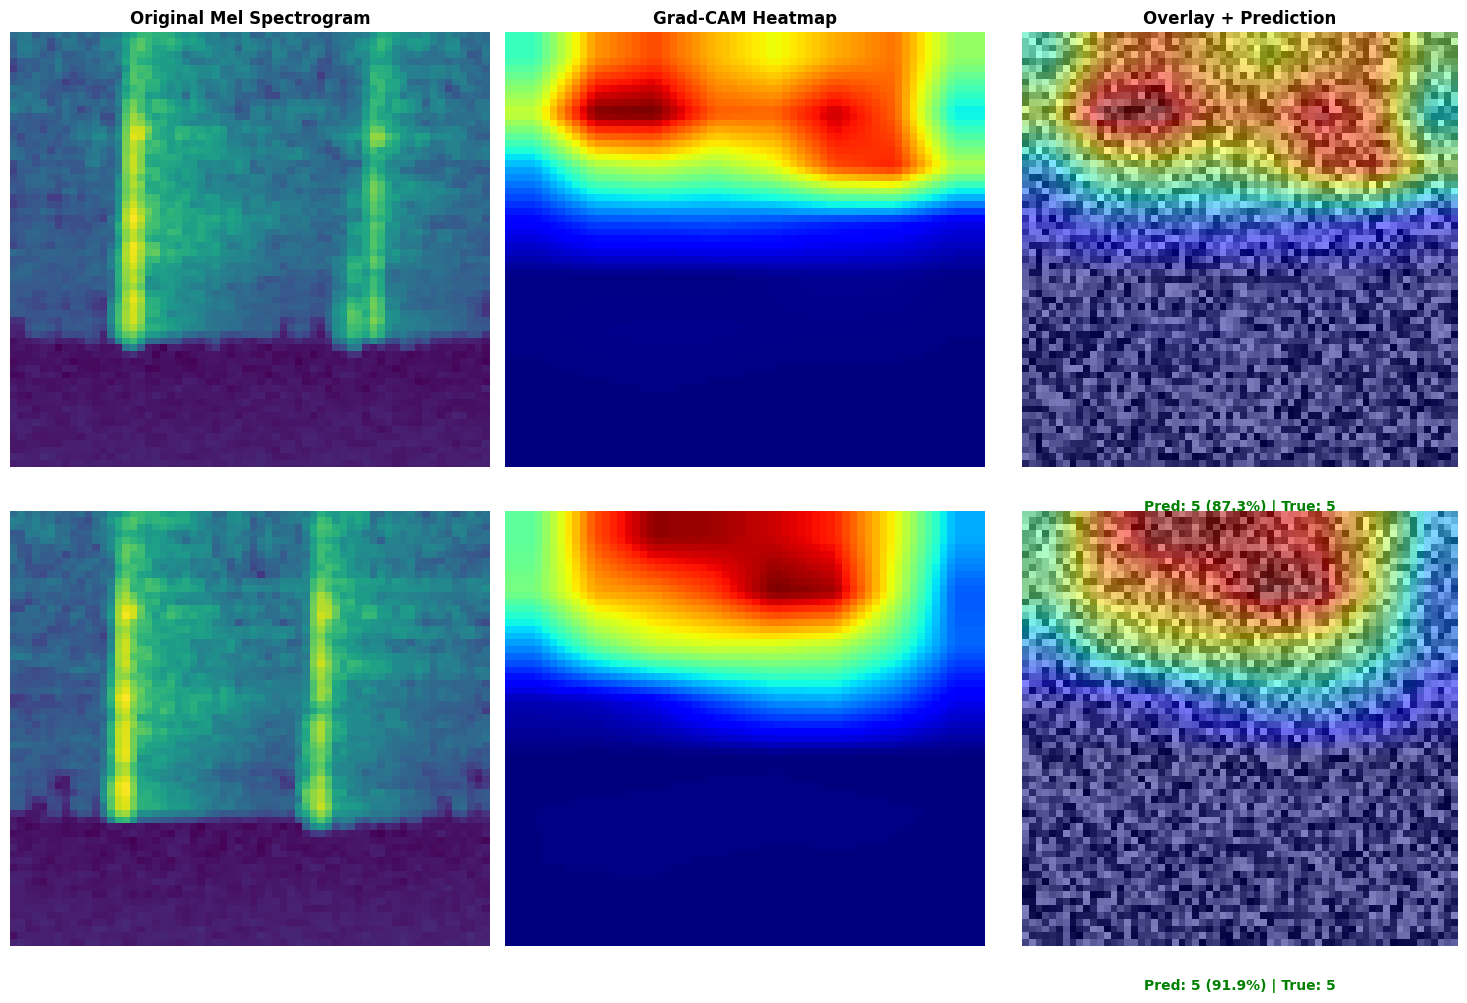


📊 Grad-CAM Analysis for Key: '9'


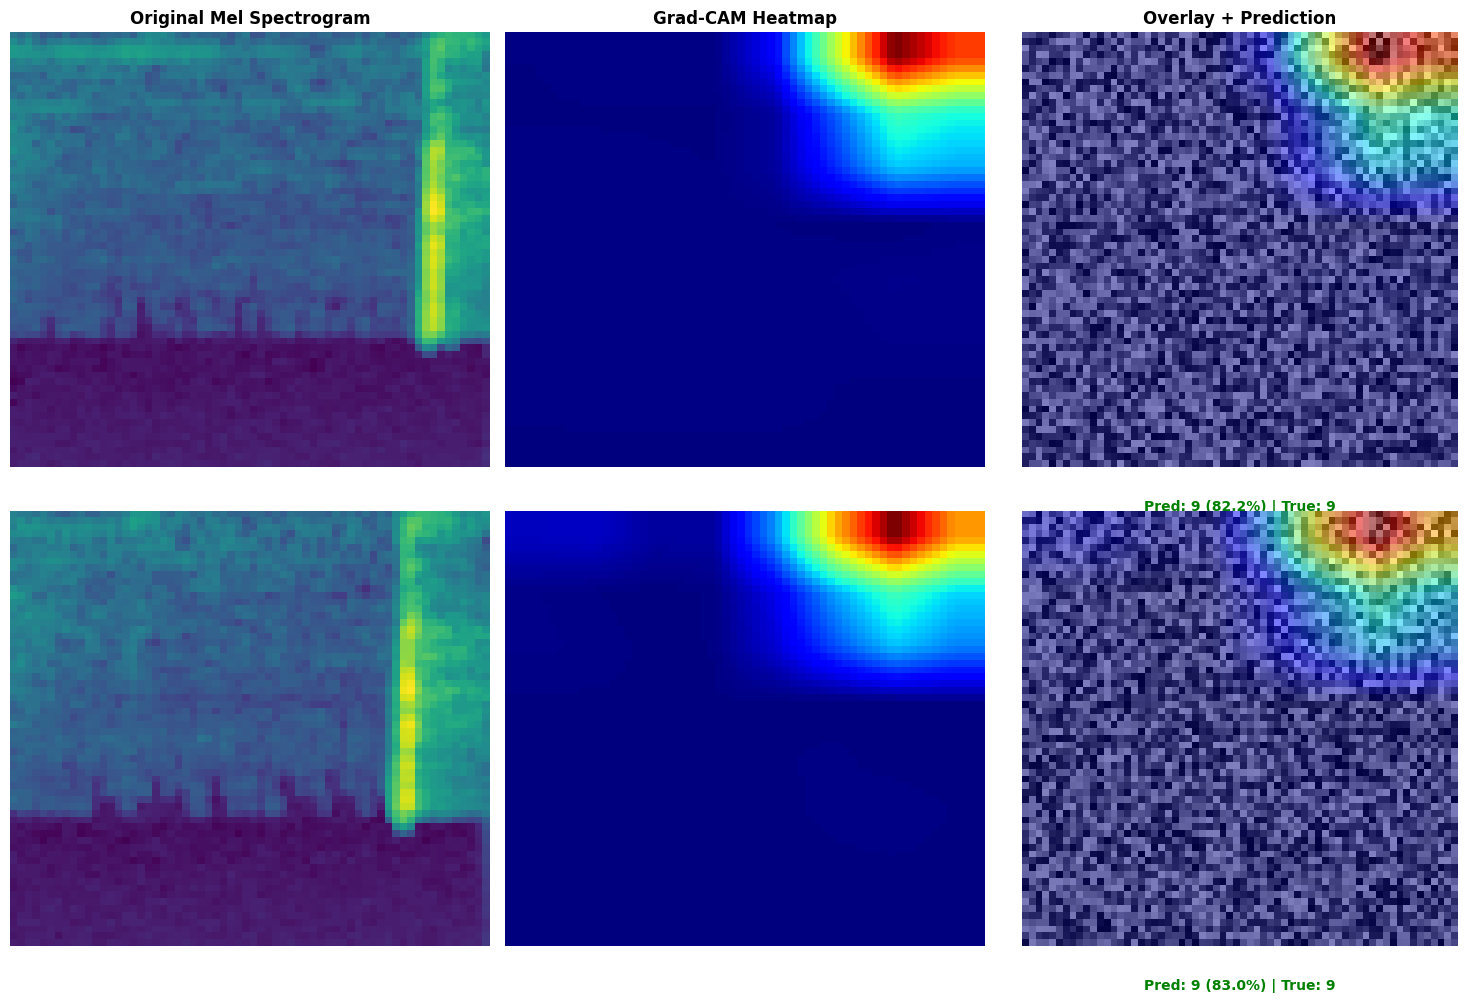

In [27]:
# Analyze specific keys (e.g., compare 'a', 'e', '5', '9')
target_keys = ['a', 'e', '5', '9']  # Change these to any keys you want to analyze

# Create reverse label mapping
label_to_idx = {v: k for k, v in idx_to_label.items()}

# Collect samples for target keys
key_samples = {key: [] for key in target_keys}

print(f"🔍 Collecting samples for keys: {target_keys}...")

for i in range(len(test_set)):
    spec_tensor, true_label = test_set[i]
    true_char = idx_to_label.get(true_label.item(), None)
    
    if true_char in target_keys and len(key_samples[true_char]) < 2:
        key_samples[true_char].append((spec_tensor, true_label))
    
    # Stop when we have enough samples for all keys
    if all(len(samples) >= 2 for samples in key_samples.values()):
        break

# Visualize Grad-CAM for each key
for key in target_keys:
    if len(key_samples[key]) > 0:
        print(f"\n📊 Grad-CAM Analysis for Key: '{key.upper()}'")
        plot_gradcam_grid(
            key_samples[key], 
            model_gradcam, 
            gradcam, 
            idx_to_label=idx_to_label,
            n_samples=len(key_samples[key])
        )
    else:
        print(f"⚠️ No samples found for key '{key}' in test set")

## 📖 Interpreting Grad-CAM Results

### What to Look For

**Good Signs (Model Learning Correctly):**
- 🟢 **Focused attention on keystroke burst**: Heatmap highlights the bright region in the spectrogram where the key press sound occurs
- 🟢 **Temporal localization**: Attention is concentrated in a specific time window (horizontal region)
- 🟢 **Frequency patterns**: Attention may focus on specific frequency bands unique to different keys
- 🟢 **Consistent patterns**: Similar keys show similar attention patterns

**Warning Signs (Potential Issues):**
- 🔴 **Random/scattered attention**: Heatmap shows no clear pattern or focuses on noise regions
- 🔴 **Edge artifacts**: Model focuses on edges of the spectrogram (dataset artifact)
- 🔴 **Background focus**: Attention on low-energy regions (background noise)
- 🔴 **Inconsistent patterns**: Same key shows very different attention patterns

### Understanding the Visualizations

1. **Original Mel Spectrogram**: Shows the input to the model
   - Brighter regions = higher energy/volume
   - Keystroke typically appears as a vertical bright band
   - Frequency on Y-axis, Time on X-axis

2. **Grad-CAM Heatmap**: Shows model's attention
   - Red = high importance (model focuses here)
   - Blue = low importance (model ignores this)
   - Indicates which regions influenced the prediction

3. **Overlay**: Combines both for easy interpretation
   - Red overlay on keystroke = good (model learning correctly)
   - Red overlay on noise = bad (model learning wrong features)

### Next Steps

Based on Grad-CAM analysis, you can:
- ✅ **Validate model performance**: Confirm model focuses on keystroke sounds
- ✅ **Debug misclassifications**: Understand why certain predictions fail
- ✅ **Improve data quality**: Identify if dataset has artifacts
- ✅ **Tune augmentation**: Adjust noise augmentation based on what model learns
- ✅ **Document results**: Use visualizations in reports/presentations

### Tips for Publication/Presentation

- Show examples of both correct and incorrect predictions
- Compare attention patterns for easily confused keys (e.g., 'p' vs 'q')
- Demonstrate that attention focuses on keystroke burst, not noise
- Use Grad-CAM to explain why certain keys are harder to classify

---

## 🎉 Grad-CAM Implementation Complete!

You now have a complete Grad-CAM analysis toolkit integrated into your notebook. The implementation includes:

✅ **GradCAM Class**: Core implementation with PyTorch hooks  
✅ **Visualization Functions**: Single and multi-sample plotting  
✅ **Label Mapping**: Automatic character label conversion  
✅ **Test Analysis**: Individual sample examination  
✅ **Batch Visualization**: Grid view of multiple samples  
✅ **Comparison Tools**: Correct vs incorrect prediction analysis  
✅ **Key-Specific Analysis**: Per-character visualization  
✅ **Interpretation Guide**: How to read and understand results  

**To use this analysis:**
1. Train your model (if not already done)
2. Run the Grad-CAM initialization cells
3. Execute visualization cells to see where your model focuses
4. Interpret results using the guidelines provided

**Note**: This implementation stays in your main notebook for convenience. If you prefer, you can copy the Grad-CAM cells to a separate notebook like `gradcam_analysis.ipynb` for cleaner organization.